# 08 — Detector-level Pyramid WFS forward model with atmospheric turbulence

This notebook uses the project-level `pwfs_forward.py` backend instead of re-defining PWFS functions inside the notebook.

Main chain:

```text
atmospheric phase screen
→ Fourier-optics PWFS propagation
→ four re-imaged pupil images on detector
→ photon/read-noise detector image
→ Sx/Sy signal vector
→ modal reconstruction
→ residual wavefront and PSF/Strehl diagnostics
```

The interaction matrix is calibrated noiselessly/high-SNR, while the science measurement can be detector-level noisy.

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm

from zernike import generate_zernike_modes, rms
from phase_screen import fourier_phase_screen
from phase_screen import frozen_flow_shift_physical
from psf_tools import compute_psf_from_phase, strehl_ratio, marechal_strehl

from pwfs_forward import (
    make_pwfs_grid,
    make_aligned_pupil_mask,
    pyramid_phase_mask,
    check_pwfs_geometry,
    pwfs_intensity,
    pwfs_signal_maps_from_intensity,
    pwfs_signal_from_intensity,
    pwfs_measurement_from_phase,
    pwfs_detector_measurement_from_phase,
    calibrate_pwfs_interaction_matrix,
    add_detector_noise,
)

## Configuration

`N_PUPIL=128`, `N_FFT=384`, and `PYRAMID_SEPARATION=96` are the high-resolution settings used for cleaner figures.  
For quicker exploratory runs, reduce them together, e.g. `96, 288, 72`.

In [122]:
# -----------------------------
# PWFS geometry and AO settings
# 10 m telescope version
# -----------------------------

# ------------------------------------------------------------
# Telescope / numerical sampling
# ------------------------------------------------------------

DIAMETER_M = 10.0

# Pupil sampling.
# 256 px across 10 m gives:
#   delta = 10 / 256 = 0.039 m / pixel
# For r0 = 0.15 m, this gives about 3.8 pixels per r0.
N_PUPIL = 256

# PWFS Fourier propagation grid.
# Keep the propagation patch about 3D wide, as in the previous 1 m notebook.
N_FFT = 3 * N_PUPIL

# Four re-imaged pupil separation on the PWFS detector.
# This preserves the previous ratio: 96 / 128 = 0.75.
PYRAMID_SEPARATION = int(0.75 * N_PUPIL)

CENTRAL_OBSCURATION = 0.0


# ------------------------------------------------------------
# Modal basis and reconstructor
# ------------------------------------------------------------

# For a 10 m aperture, 14 modes is too low unless you explicitly want
# a very low-order correction test. 50 modes is still modest but more meaningful.
MAX_RADIAL_ORDER = 9
N_MODES = 50

# Interaction-matrix calibration amplitude in rad phase.
CALIB_AMP = 1e-3

# SVD truncation threshold. Larger values are more stable but discard more modes.
RCOND = 3e-3


# ------------------------------------------------------------
# PWFS modulation
# ------------------------------------------------------------

# Modulation radius in lambda/D units.
# 0.0: maximum sensitivity, small linear range.
# 1.0: more robust atmospheric residual demo.
MODULATION_RADIUS = 1.0

# Number of discrete points used to approximate circular modulation.
N_MODULATION_POINTS = 12


# ------------------------------------------------------------
# Atmospheric phase-screen parameters
# ------------------------------------------------------------

# Fried parameter and outer scale.
# D / r0 = 10 / 0.15 ~ 67, i.e. a large-aperture regime.
R0_M = 0.15
L0_M = 25.0
WAVELENGTH_M = 500e-9

# Important:
# This notebook still uses a target RMS normalization.
# Therefore ATM_TARGET_RMS_RAD should be interpreted as a controlled
# residual-like atmospheric input, not a full uncorrected 10 m seeing screen.
ATM_TARGET_RMS_RAD = 0.50
ATM_SEED = 11


# ------------------------------------------------------------
# Detector-level measurement
# ------------------------------------------------------------

# Total detected photons per PWFS frame.
# For 50 modes and a 10 m toy system, keep this reasonably high first.
N_PHOTONS = 5e6

# Read noise in electrons RMS per pixel.
READ_NOISE_E = 0.5

DETECTOR_SEED = 5


# ------------------------------------------------------------
# PSF / closed-loop diagnostics
# ------------------------------------------------------------

PSF_PAD_FACTOR = 4

PSEUDO_LOOP_ITERS = 12
PSEUDO_LOOP_GAIN = 0.20
PSEUDO_LOOP_USE_DETECTOR_NOISE = False

RUN_DETECTOR_NOISE_SCAN = False

rng = np.random.default_rng(7)


# ------------------------------------------------------------
# Sanity prints
# ------------------------------------------------------------

delta_pupil = DIAMETER_M / N_PUPIL

print("10 m PWFS configuration:")
print(f"  telescope diameter D        = {DIAMETER_M:.2f} m")
print(f"  pupil sampling              = {N_PUPIL} px across D")
print(f"  pupil pixel scale           = {delta_pupil:.4f} m / px")
print(f"  r0                          = {R0_M:.3f} m")
print(f"  D / r0                      = {DIAMETER_M / R0_M:.1f}")
print(f"  pixels per r0               = {R0_M / delta_pupil:.2f}")
print(f"  PWFS FFT grid               = {N_FFT} px = {N_FFT / N_PUPIL:.1f} D")
print(f"  pyramid pupil separation    = {PYRAMID_SEPARATION} px")
print(f"  controlled modes            = {N_MODES}")
print(f"  modulation radius           = {MODULATION_RADIUS:.2f} lambda/D")

10 m PWFS configuration:
  telescope diameter D        = 10.00 m
  pupil sampling              = 256 px across D
  pupil pixel scale           = 0.0391 m / px
  r0                          = 0.150 m
  D / r0                      = 66.7
  pixels per r0               = 3.84
  PWFS FFT grid               = 768 px = 3.0 D
  pyramid pupil separation    = 192 px
  controlled modes            = 50
  modulation radius           = 1.00 lambda/D


## Helper functions

In [66]:
def svd_reconstructor(A, rcond=1e-3):
    """Return TSVD reconstructor R and singular-value diagnostics."""
    U, S, Vt = np.linalg.svd(np.asarray(A, dtype=float), full_matrices=False)
    keep = S / S[0] >= rcond

    Sinv = np.zeros_like(S)
    Sinv[keep] = 1.0 / S[keep]

    R = Vt.T @ np.diag(Sinv) @ U.T
    return R, S, keep


def synthesize_from_coeffs(coeffs, modes_dict, mode_names, mask):
    """Synthesize a phase map from modal coefficients."""
    coeffs = np.asarray(coeffs, dtype=float)

    phase = np.zeros_like(next(iter(modes_dict.values())), dtype=float)
    for c, name in zip(coeffs, mode_names):
        phase += float(c) * np.nan_to_num(modes_dict[name], nan=0.0)

    phase = np.where(mask, phase, 0.0)
    phase[mask] -= np.mean(phase[mask])
    return phase


def project_phase_onto_modes(phase, modes_dict, mode_names, mask):
    """
    Least-squares projection of an arbitrary phase map onto a possibly
    non-perfectly-orthogonal discrete Zernike basis.
    """
    phase_vals = np.asarray(phase, dtype=float)[mask]
    phase_vals = phase_vals - np.mean(phase_vals)

    M = np.column_stack([
        np.nan_to_num(modes_dict[name], nan=0.0)[mask]
        for name in mode_names
    ])

    coeffs, *_ = np.linalg.lstsq(M, phase_vals, rcond=None)
    return coeffs


def residual_wavefront(phase_true, phase_rec, mask):
    """Residual phase map and RMS after piston removal."""
    residual = np.asarray(phase_true, dtype=float) - np.asarray(phase_rec, dtype=float)
    residual = np.where(mask, residual, np.nan)
    residual[mask] -= np.nanmean(residual[mask])
    residual_rms = rms(residual, mask)
    return residual, residual_rms


def plot_phase(ax, arr, mask, title, cmap=None):
    im = ax.imshow(
        np.where(mask, arr, np.nan),
        origin="lower",
        interpolation="bilinear",
        cmap=cmap,
    )
    ax.set_title(title)
    ax.axis("off")
    return im

## PWFS geometry and Zernike modal basis

In [123]:
# -----------------------------
# PWFS grid
# -----------------------------

check_pwfs_geometry(
    n_fft=N_FFT,
    n_pupil=N_PUPIL,
    separation=PYRAMID_SEPARATION,
)

x_pw, y_pw, rho_pw, theta_pw, pupil_pw = make_pwfs_grid(
    n_fft=N_FFT,
    n_pupil=N_PUPIL,
    central_obscuration=CENTRAL_OBSCURATION,
)

aligned_mask = make_aligned_pupil_mask(
    n_pupil=N_PUPIL,
    central_obscuration=CENTRAL_OBSCURATION,
)

pyramid_mask_pw = pyramid_phase_mask(
    n_fft=N_FFT,
    separation=PYRAMID_SEPARATION,
)

modes_pw_all = generate_zernike_modes(
    rho_pw,
    theta_pw,
    pupil_pw,
    max_radial_order=MAX_RADIAL_ORDER,
    include_piston=False,
    normalization=True,
)

mode_names = list(modes_pw_all.keys())[:N_MODES]
modes_pw = {
    name: np.nan_to_num(modes_pw_all[name], nan=0.0)
    for name in mode_names
}

print("PWFS full FFT grid:", pupil_pw.shape)
print("Physical pupil pixels:", int(np.sum(pupil_pw)))
print("Aligned pupil signal pixels:", int(np.sum(aligned_mask)))
print("Number of calibrated modes:", len(mode_names))
print(mode_names)

PWFS full FFT grid: (768, 768)
Physical pupil pixels: 51433
Aligned pupil signal pixels: 51431
Number of calibrated modes: 50
['Z1_+1', 'Z1_-1', 'Z2_+0', 'Z2_+2', 'Z2_-2', 'Z3_+1', 'Z3_-1', 'Z3_+3', 'Z3_-3', 'Z4_+0', 'Z4_+2', 'Z4_-2', 'Z4_+4', 'Z4_-4', 'Z5_+1', 'Z5_-1', 'Z5_+3', 'Z5_-3', 'Z5_+5', 'Z5_-5', 'Z6_+0', 'Z6_+2', 'Z6_-2', 'Z6_+4', 'Z6_-4', 'Z6_+6', 'Z6_-6', 'Z7_+1', 'Z7_-1', 'Z7_+3', 'Z7_-3', 'Z7_+5', 'Z7_-5', 'Z7_+7', 'Z7_-7', 'Z8_+0', 'Z8_+2', 'Z8_-2', 'Z8_+4', 'Z8_-4', 'Z8_+6', 'Z8_-6', 'Z8_+8', 'Z8_-8', 'Z9_+1', 'Z9_-1', 'Z9_+3', 'Z9_-3', 'Z9_+5', 'Z9_-5']


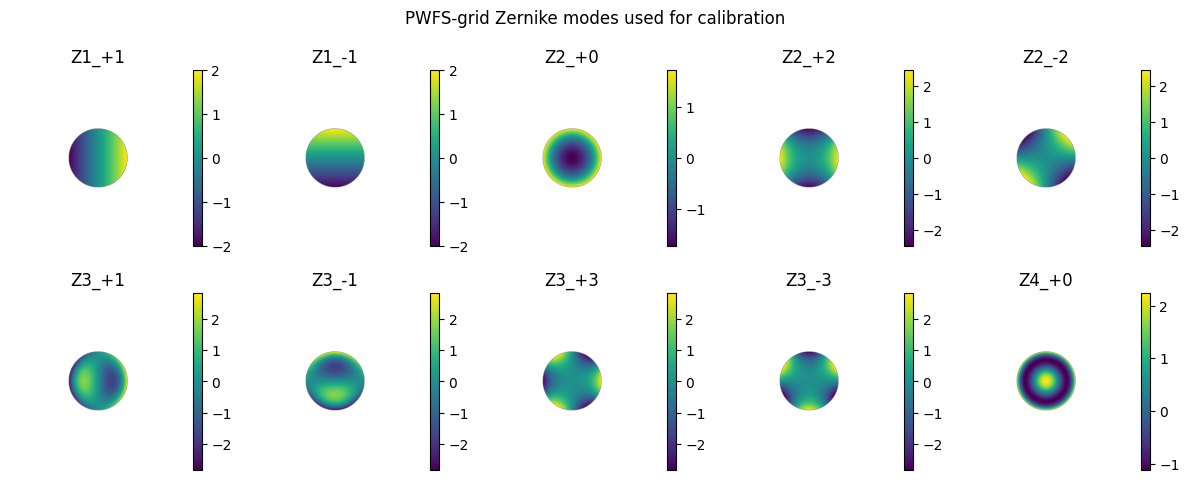

In [124]:
# Visualize first few calibrated modes on the padded PWFS grid
n_show = min(10, len(mode_names))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, name in zip(axes.ravel(), mode_names[:n_show]):
    im = plot_phase(ax, modes_pw[name], pupil_pw, name)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes.ravel()[n_show:]:
    ax.axis("off")

plt.suptitle("PWFS-grid Zernike modes used for calibration")
plt.tight_layout()
plt.show()

## Atmospheric turbulence input

In [125]:
delta_pw = DIAMETER_M / N_PUPIL

phase_atm_raw, X_atm, Y_atm, mask_atm = fourier_phase_screen(
    N=N_FFT,
    delta=delta_pw,
    r0=R0_M,
    L0=L0_M,
    diameter=DIAMETER_M,
    wavelength=WAVELENGTH_M,
    seed=ATM_SEED,
    target_rms_rad=ATM_TARGET_RMS_RAD,
    normalize_rms=True,
)

# Use the PWFS pupil mask as the final optical aperture.
phase_atm = np.where(pupil_pw, np.nan_to_num(phase_atm_raw, nan=0.0), 0.0)
phase_atm[pupil_pw] -= np.mean(phase_atm[pupil_pw])

coeff_atm = project_phase_onto_modes(
    phase_atm,
    modes_pw,
    mode_names,
    pupil_pw,
)

phase_atm_modal = synthesize_from_coeffs(
    coeff_atm,
    modes_pw,
    mode_names,
    pupil_pw,
)

phase_fitting, fitting_rms = residual_wavefront(
    phase_atm,
    phase_atm_modal,
    pupil_pw,
)

print("Atmospheric input:")
print(f"  input RMS             = {rms(phase_atm, pupil_pw):.4e} rad")
print(f"  fitting-error floor   = {fitting_rms:.4e} rad")

Atmospheric input:
  input RMS             = 5.0000e-01 rad
  fitting-error floor   = 1.0508e-01 rad


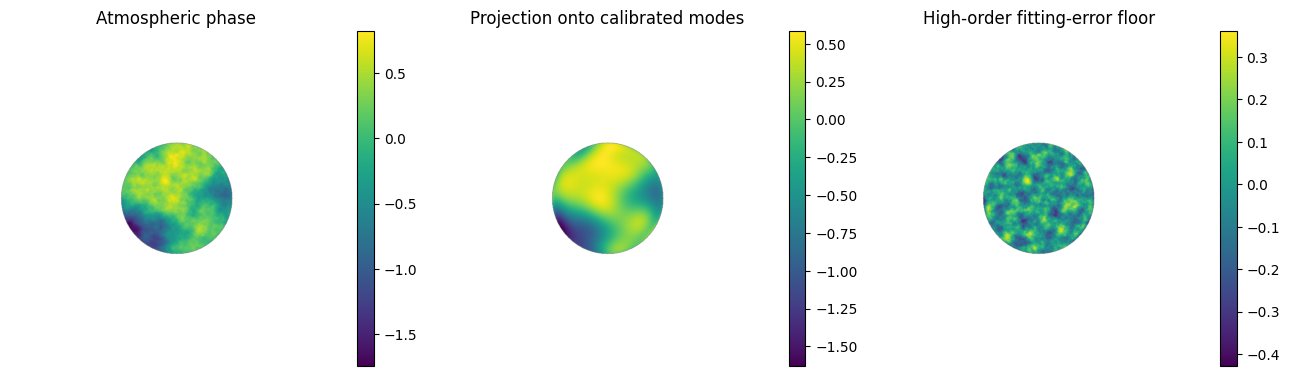

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, arr, title in zip(
    axes,
    [phase_atm, phase_atm_modal, phase_fitting],
    [
        "Atmospheric phase",
        "Projection onto calibrated modes",
        "High-order fitting-error floor",
    ],
):
    im = plot_phase(ax, arr, pupil_pw, title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Detector-level PWFS images and signal maps

In [127]:
# -----------------------------
# Noiseless and noisy detector images
# -----------------------------

phase_flat = np.zeros_like(phase_atm)

intensity_flat = pwfs_intensity(
    phase_flat,
    pupil=pupil_pw,
    x=x_pw,
    y=y_pw,
    pyramid_mask=pyramid_mask_pw,
    separation=PYRAMID_SEPARATION,
    modulation_radius=MODULATION_RADIUS,
    n_modulation_points=N_MODULATION_POINTS,
)

intensity_atm = pwfs_intensity(
    phase_atm,
    pupil=pupil_pw,
    x=x_pw,
    y=y_pw,
    pyramid_mask=pyramid_mask_pw,
    separation=PYRAMID_SEPARATION,
    modulation_radius=MODULATION_RADIUS,
    n_modulation_points=N_MODULATION_POINTS,
)

noisy_intensity_atm = add_detector_noise(
    intensity_atm,
    n_photons=N_PHOTONS,
    read_noise_e=READ_NOISE_E,
    seed=DETECTOR_SEED,
)

Sx_noisy, Sy_noisy, total_noisy, valid_signal = pwfs_signal_maps_from_intensity(
    noisy_intensity_atm,
    n_pupil=N_PUPIL,
    separation=PYRAMID_SEPARATION,
    central_obscuration=CENTRAL_OBSCURATION,
)

print("Detector-level PWFS image diagnostics:")
print(f"  photons requested       = {N_PHOTONS:.3e}")
print(f"  noisy detector sum      = {np.sum(noisy_intensity_atm):.3e} e-")
print(f"  signal vector length    = {2 * int(np.sum(valid_signal))}")

Detector-level PWFS image diagnostics:
  photons requested       = 5.000e+06
  noisy detector sum      = 5.031e+06 e-
  signal vector length    = 102862


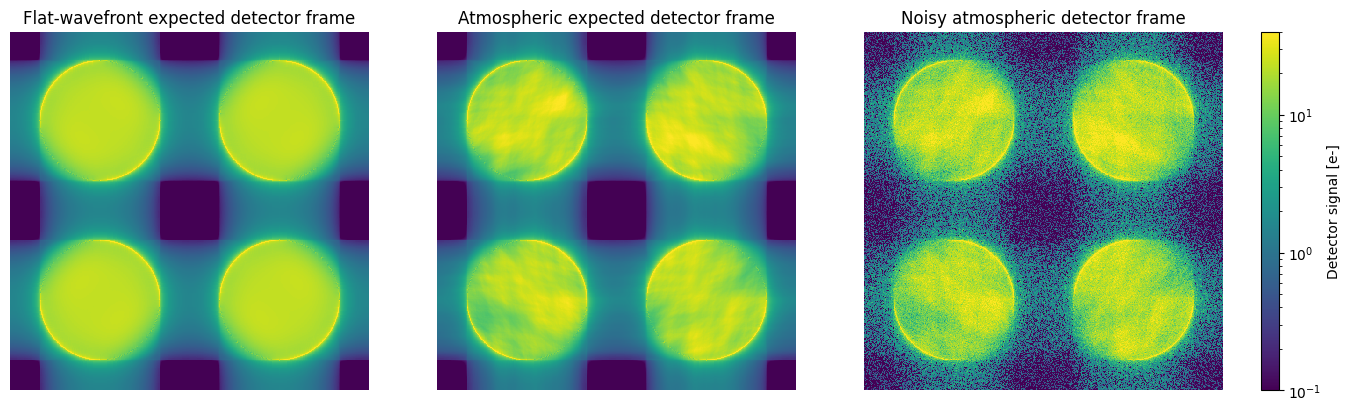

In [128]:
# ------------------------------------------------------------
# PWFS detector images in comparable electron-count units
# ------------------------------------------------------------

def to_expected_electrons(intensity, n_photons):
    """
    Convert arbitrary optical intensity to expected detector electrons.
    """
    intensity = np.asarray(intensity, dtype=float)
    intensity = np.clip(intensity, 0.0, None)
    total = np.sum(intensity)

    if total <= 0:
        raise ValueError("Intensity image has zero total flux.")

    return intensity / total * n_photons


def positive_log_limits(images, low_percentile=1.0, high_percentile=99.5):
    vals = []

    for img in images:
        img = np.asarray(img, dtype=float)
        good = np.isfinite(img) & (img > 0)
        if np.any(good):
            vals.append(img[good].ravel())

    if len(vals) == 0:
        return 1e-3, 1.0

    vals = np.concatenate(vals)

    vmin = np.percentile(vals, low_percentile)
    vmax = np.percentile(vals, high_percentile)

    # For electron-count images, avoid showing sub-electron noise too aggressively.
    vmin = max(vmin, 0.1)
    vmax = max(vmax, 10.0 * vmin)

    return vmin, vmax


# Convert noiseless optical intensities to expected electron frames.
expected_flat_e = to_expected_electrons(
    intensity_flat,
    n_photons=N_PHOTONS,
)

expected_atm_e = to_expected_electrons(
    intensity_atm,
    n_photons=N_PHOTONS,
)

# noisy_intensity_atm is already in electron units.
detector_images = [
    expected_flat_e,
    expected_atm_e,
    noisy_intensity_atm,
]

titles = [
    "Flat-wavefront expected detector frame",
    "Atmospheric expected detector frame",
    "Noisy atmospheric detector frame",
]

vmin_det, vmax_det = positive_log_limits(
    detector_images,
    low_percentile=1.0,
    high_percentile=99.5,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4),
    constrained_layout=True,
)

for ax, img, title in zip(axes, detector_images, titles):
    im = ax.imshow(
        img + 1e-12,
        origin="lower",
        norm=LogNorm(vmin=vmin_det, vmax=vmax_det),
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(
    im,
    ax=axes,
    fraction=0.025,
    pad=0.03,
    label="Detector signal [e-]",
)

plt.show()

In [129]:
Sx_clean, Sy_clean, _, valid_signal = pwfs_signal_maps_from_intensity(
    intensity_atm,
    n_pupil=N_PUPIL,
    separation=PYRAMID_SEPARATION,
    central_obscuration=CENTRAL_OBSCURATION,
)

Sx_noisy, Sy_noisy, _, valid_signal = pwfs_signal_maps_from_intensity(
    noisy_intensity_atm,
    n_pupil=N_PUPIL,
    separation=PYRAMID_SEPARATION,
    central_obscuration=CENTRAL_OBSCURATION,
)

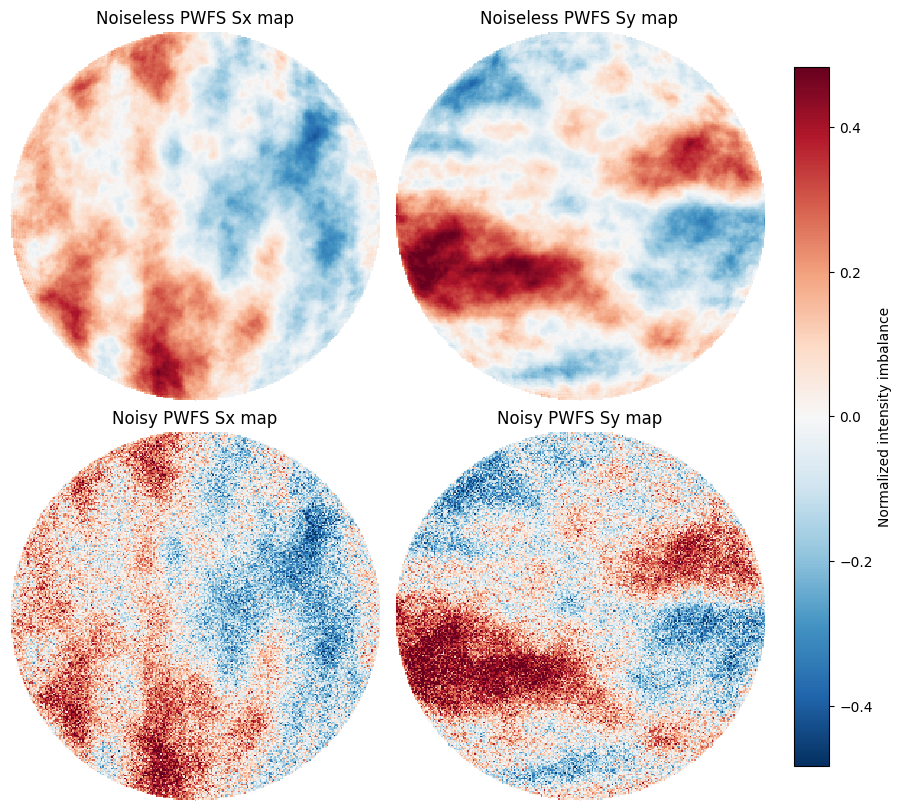

In [130]:
# ------------------------------------------------------------
# Clean vs noisy PWFS Sx/Sy maps
# ------------------------------------------------------------

maps = [
    np.where(valid_signal, Sx_clean, np.nan),
    np.where(valid_signal, Sy_clean, np.nan),
    np.where(valid_signal, Sx_noisy, np.nan),
    np.where(valid_signal, Sy_noisy, np.nan),
]

titles = [
    "Noiseless PWFS Sx map",
    "Noiseless PWFS Sy map",
    "Noisy PWFS Sx map",
    "Noisy PWFS Sy map",
]

vals = np.concatenate([
    m[np.isfinite(m)].ravel()
    for m in maps
])

signal_absmax = np.nanpercentile(np.abs(vals), 99.0)
signal_absmax = max(signal_absmax, 1e-6)

signal_norm = TwoSlopeNorm(
    vmin=-signal_absmax,
    vcenter=0.0,
    vmax=signal_absmax,
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(9, 8),
    constrained_layout=True,
)

for ax, m, title in zip(axes.ravel(), maps, titles):
    im = ax.imshow(
        m,
        origin="lower",
        interpolation="nearest",
        cmap="RdBu_r",
        norm=signal_norm,
    )
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    fraction=0.046,
    pad=0.04,
    label="Normalized intensity imbalance",
)

plt.show()

## PWFS interaction matrix calibration

PWFS interaction matrix: (102862, 50)
Condition number: 6.997e+00
TSVD kept modes: 50 / 50


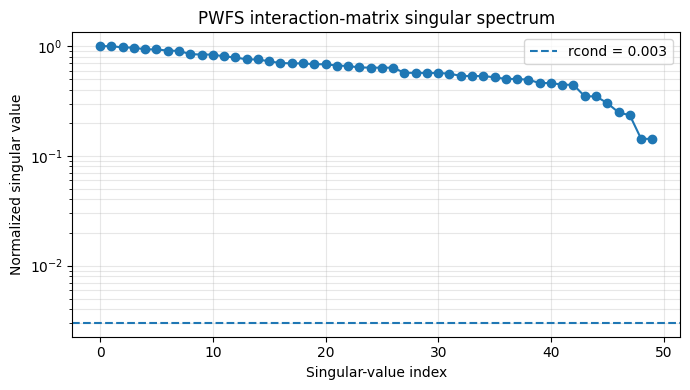

In [131]:
# -----------------------------
# Noiseless/high-SNR interaction matrix
# -----------------------------

A_pw, names_pw, reference_pw = calibrate_pwfs_interaction_matrix(
    modes_pw,
    pupil=pupil_pw,
    x=x_pw,
    y=y_pw,
    calibration_amplitude=CALIB_AMP,
    n_pupil=N_PUPIL,
    separation=PYRAMID_SEPARATION,
    central_obscuration=CENTRAL_OBSCURATION,
    pyramid_mask=pyramid_mask_pw,
    modulation_radius=MODULATION_RADIUS,
    n_modulation_points=N_MODULATION_POINTS,
    differential=True,
)

assert names_pw == mode_names

R_pw, S_pw, keep_pw = svd_reconstructor(A_pw, rcond=RCOND)
cond_pw = S_pw[0] / S_pw[-1]

print("PWFS interaction matrix:", A_pw.shape)
print(f"Condition number: {cond_pw:.3e}")
print(f"TSVD kept modes: {keep_pw.sum()} / {len(keep_pw)}")

plt.figure(figsize=(7, 4))
plt.semilogy(S_pw / S_pw[0], "o-")
plt.axhline(RCOND, linestyle="--", label=f"rcond = {RCOND}")
plt.xlabel("Singular-value index")
plt.ylabel("Normalized singular value")
plt.title("PWFS interaction-matrix singular spectrum")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

## Controlled low-order modal reconstruction

In [132]:
# -----------------------------
# Modal benchmark: input lies inside calibrated modal space
# -----------------------------

true_coeffs = rng.normal(0.0, 0.05, size=len(mode_names))
true_coeffs *= np.linspace(1.0, 0.4, len(mode_names))

phase_modal_true = synthesize_from_coeffs(
    true_coeffs,
    modes_pw,
    mode_names,
    pupil_pw,
)

s_modal_noiseless = pwfs_measurement_from_phase(
    phase_modal_true,
    pupil=pupil_pw,
    x=x_pw,
    y=y_pw,
    reference_signal=reference_pw,
    n_pupil=N_PUPIL,
    separation=PYRAMID_SEPARATION,
    central_obscuration=CENTRAL_OBSCURATION,
    pyramid_mask=pyramid_mask_pw,
    modulation_radius=MODULATION_RADIUS,
    n_modulation_points=N_MODULATION_POINTS,
)

s_modal_noisy = pwfs_detector_measurement_from_phase(
    phase_modal_true,
    pupil=pupil_pw,
    x=x_pw,
    y=y_pw,
    reference_signal=reference_pw,
    n_photons=N_PHOTONS,
    read_noise_e=READ_NOISE_E,
    seed=DETECTOR_SEED + 1,
    n_pupil=N_PUPIL,
    separation=PYRAMID_SEPARATION,
    central_obscuration=CENTRAL_OBSCURATION,
    pyramid_mask=pyramid_mask_pw,
    modulation_radius=MODULATION_RADIUS,
    n_modulation_points=N_MODULATION_POINTS,
)

rec_coeffs_noiseless = R_pw @ s_modal_noiseless
rec_coeffs_noisy = R_pw @ s_modal_noisy

phase_rec_noiseless = synthesize_from_coeffs(rec_coeffs_noiseless, modes_pw, mode_names, pupil_pw)
phase_rec_noisy = synthesize_from_coeffs(rec_coeffs_noisy, modes_pw, mode_names, pupil_pw)

res_noiseless, res_rms_noiseless = residual_wavefront(
    phase_modal_true,
    phase_rec_noiseless,
    pupil_pw,
)

res_noisy, res_rms_noisy = residual_wavefront(
    phase_modal_true,
    phase_rec_noisy,
    pupil_pw,
)

print("Modal benchmark:")
print(f"  input RMS                  = {rms(phase_modal_true, pupil_pw):.4e} rad")
print(f"  residual RMS, noiseless    = {res_rms_noiseless:.4e} rad")
print(f"  residual RMS, detector     = {res_rms_noisy:.4e} rad")
print(f"  coeff error, noiseless     = {np.linalg.norm(rec_coeffs_noiseless - true_coeffs) / np.linalg.norm(true_coeffs):.4e}")
print(f"  coeff error, detector      = {np.linalg.norm(rec_coeffs_noisy - true_coeffs) / np.linalg.norm(true_coeffs):.4e}")

Modal benchmark:
  input RMS                  = 2.2455e-01 rad
  residual RMS, noiseless    = 1.1519e-02 rad
  residual RMS, detector     = 1.2930e-02 rad
  coeff error, noiseless     = 5.1614e-02
  coeff error, detector      = 5.7834e-02


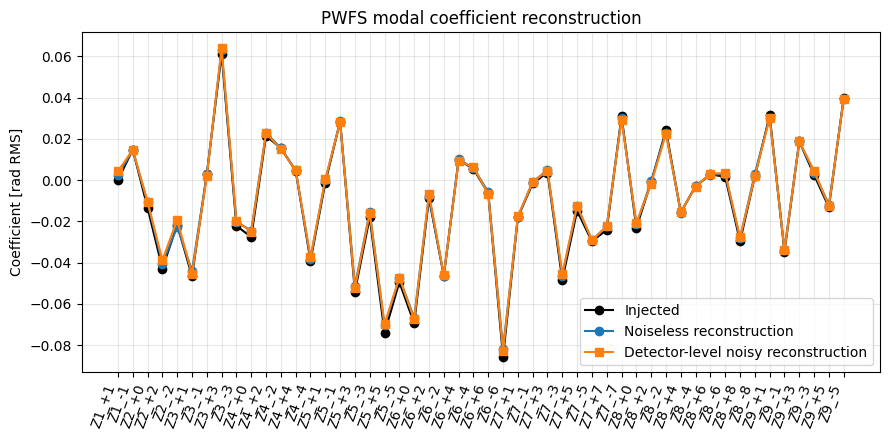

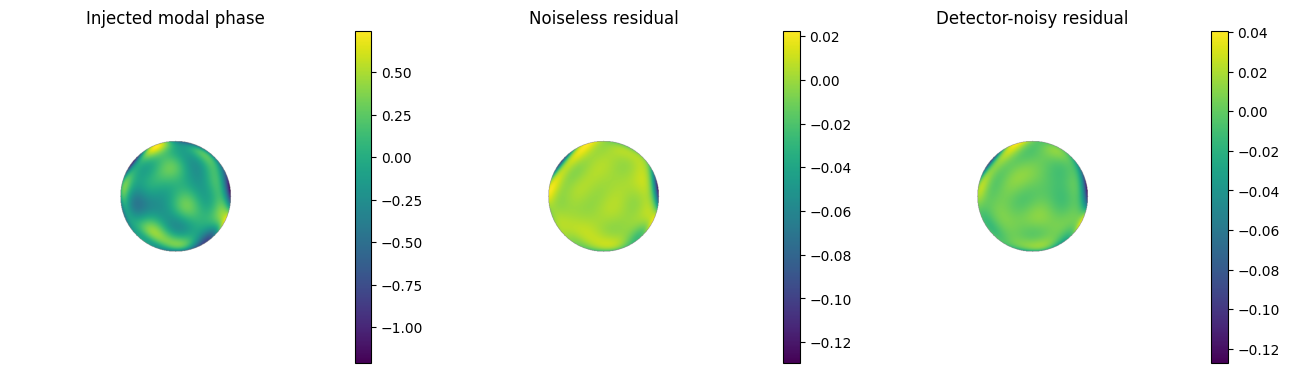

In [133]:
plt.figure(figsize=(9, 4.5))
plt.plot(true_coeffs, "ko-", label="Injected")
plt.plot(rec_coeffs_noiseless, "o-", label="Noiseless reconstruction")
plt.plot(rec_coeffs_noisy, "s-", label="Detector-level noisy reconstruction")
plt.xticks(np.arange(len(mode_names)), mode_names, rotation=70, ha="right")
plt.ylabel("Coefficient [rad RMS]")
plt.title("PWFS modal coefficient reconstruction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, arr, title in zip(
    axes,
    [phase_modal_true, res_noiseless, res_noisy],
    ["Injected modal phase", "Noiseless residual", "Detector-noisy residual"],
):
    im = plot_phase(ax, arr, pupil_pw, title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Atmospheric turbulence reconstruction

In [134]:
# -----------------------------
# One-shot open-loop atmospheric diagnostic
# -----------------------------

s_atm_noiseless = pwfs_measurement_from_phase(
    phase_atm,
    pupil=pupil_pw,
    x=x_pw,
    y=y_pw,
    reference_signal=reference_pw,
    n_pupil=N_PUPIL,
    separation=PYRAMID_SEPARATION,
    central_obscuration=CENTRAL_OBSCURATION,
    pyramid_mask=pyramid_mask_pw,
    modulation_radius=MODULATION_RADIUS,
    n_modulation_points=N_MODULATION_POINTS,
)

s_atm_noisy = pwfs_detector_measurement_from_phase(
    phase_atm,
    pupil=pupil_pw,
    x=x_pw,
    y=y_pw,
    reference_signal=reference_pw,
    n_photons=N_PHOTONS,
    read_noise_e=READ_NOISE_E,
    seed=DETECTOR_SEED + 2,
    n_pupil=N_PUPIL,
    separation=PYRAMID_SEPARATION,
    central_obscuration=CENTRAL_OBSCURATION,
    pyramid_mask=pyramid_mask_pw,
    modulation_radius=MODULATION_RADIUS,
    n_modulation_points=N_MODULATION_POINTS,
)

rec_atm_noiseless = R_pw @ s_atm_noiseless
rec_atm_noisy = R_pw @ s_atm_noisy

phase_corr_noiseless = synthesize_from_coeffs(rec_atm_noiseless, modes_pw, mode_names, pupil_pw)
phase_corr_noisy = synthesize_from_coeffs(rec_atm_noisy, modes_pw, mode_names, pupil_pw)

res_atm_noiseless, res_atm_rms_noiseless = residual_wavefront(
    phase_atm,
    phase_corr_noiseless,
    pupil_pw,
)

res_atm_noisy, res_atm_rms_noisy = residual_wavefront(
    phase_atm,
    phase_corr_noisy,
    pupil_pw,
)

print("One-shot open-loop atmospheric diagnostic:")
print(f"  input RMS                         = {rms(phase_atm, pupil_pw):.4e} rad")
print(f"  fitting-error floor               = {fitting_rms:.4e} rad")
print(f"  residual RMS, noiseless one-shot  = {res_atm_rms_noiseless:.4e} rad")
print(f"  residual RMS, detector one-shot   = {res_atm_rms_noisy:.4e} rad")
print(f"  modal coeff error, noiseless      = {np.linalg.norm(rec_atm_noiseless - coeff_atm) / np.linalg.norm(coeff_atm):.4e}")
print(f"  modal coeff error, detector       = {np.linalg.norm(rec_atm_noisy - coeff_atm) / np.linalg.norm(coeff_atm):.4e}")

One-shot open-loop atmospheric diagnostic:
  input RMS                         = 5.0000e-01 rad
  fitting-error floor               = 1.0508e-01 rad
  residual RMS, noiseless one-shot  = 1.0681e-01 rad
  residual RMS, detector one-shot   = 1.0690e-01 rad
  modal coeff error, noiseless      = 3.9215e-02
  modal coeff error, detector       = 4.0270e-02


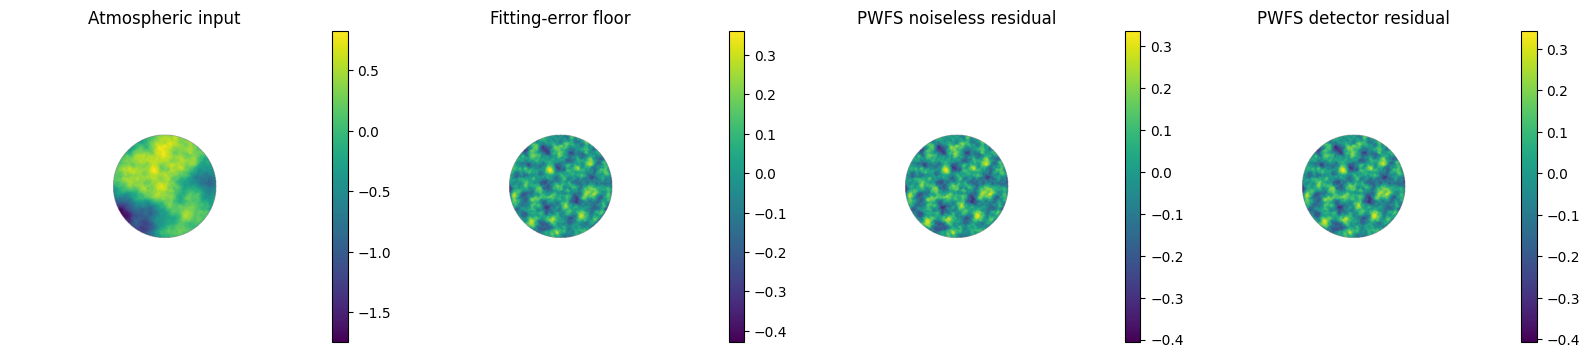

In [135]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

items = [
    (phase_atm, "Atmospheric input"),
    (phase_fitting, "Fitting-error floor"),
    (res_atm_noiseless, "PWFS noiseless residual"),
    (res_atm_noisy, "PWFS detector residual"),
]

for ax, (arr, title) in zip(axes, items):
    im = plot_phase(ax, arr, pupil_pw, title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [136]:
# ------------------------------------------------------------
# Pseudo closed-loop PWFS correction
# ------------------------------------------------------------

def pseudo_closed_loop_pwfs(
    phase_input,
    n_iter=PSEUDO_LOOP_ITERS,
    gain=PSEUDO_LOOP_GAIN,
    use_detector_noise=PSEUDO_LOOP_USE_DETECTOR_NOISE,
    n_photons=N_PHOTONS,
    read_noise_e=READ_NOISE_E,
    seed=123,
):
    """
    Simple pseudo closed-loop PWFS correction for the 08 notebook.

    At each iteration:
        current residual phase
        -> PWFS measurement
        -> modal reconstruction
        -> accumulate correction with loop gain

    This is not a full real-time AO controller. It is a compact diagnostic
    showing why PWFS is normally operated around a small residual wavefront.
    """
    phase_input = np.asarray(phase_input, dtype=float)

    correction_total = np.zeros_like(phase_input)
    residual_current = np.array(phase_input, dtype=float, copy=True)
    residual_current[~pupil_pw] = 0.0
    residual_current[pupil_pw] -= np.mean(residual_current[pupil_pw])

    rng_loop = np.random.default_rng(seed)
    history = []

    for k in range(n_iter):
        if use_detector_noise:
            s = pwfs_detector_measurement_from_phase(
                phase=residual_current,
                pupil=pupil_pw,
                x=x_pw,
                y=y_pw,
                reference_signal=reference_pw,
                n_photons=n_photons,
                read_noise_e=read_noise_e,
                seed=int(rng_loop.integers(0, 2**31 - 1)),
                n_pupil=N_PUPIL,
                separation=PYRAMID_SEPARATION,
                central_obscuration=CENTRAL_OBSCURATION,
                pyramid_mask=pyramid_mask_pw,
                modulation_radius=MODULATION_RADIUS,
                n_modulation_points=N_MODULATION_POINTS,
            )
        else:
            s = pwfs_measurement_from_phase(
                phase=residual_current,
                pupil=pupil_pw,
                x=x_pw,
                y=y_pw,
                reference_signal=reference_pw,
                n_pupil=N_PUPIL,
                separation=PYRAMID_SEPARATION,
                central_obscuration=CENTRAL_OBSCURATION,
                pyramid_mask=pyramid_mask_pw,
                modulation_radius=MODULATION_RADIUS,
                n_modulation_points=N_MODULATION_POINTS,
            )

        coeff_est = R_pw @ s

        phase_est = synthesize_from_coeffs(
            coeff_est,
            modes_pw,
            mode_names,
            pupil_pw,
        )

        correction_total += gain * phase_est

        residual_map, residual_rms = residual_wavefront(
            phase_input,
            correction_total,
            pupil_pw,
        )

        residual_current = np.nan_to_num(residual_map, nan=0.0)
        residual_current[~pupil_pw] = 0.0
        residual_current[pupil_pw] -= np.mean(residual_current[pupil_pw])

        strehl_k = strehl_ratio(
            residual_current,
            pupil_pw,
            pad_factor=PSF_PAD_FACTOR,
        )

        history.append(
            {
                "iteration": k + 1,
                "residual_rms": residual_rms,
                "strehl": strehl_k,
                "coeff_norm": np.linalg.norm(coeff_est),
            }
        )

    final_residual_map, final_residual_rms = residual_wavefront(
        phase_input,
        correction_total,
        pupil_pw,
    )

    return correction_total, final_residual_map, final_residual_rms, history


correction_cl, residual_cl_map, residual_cl_rms, history_cl = pseudo_closed_loop_pwfs(
    phase_atm,
    n_iter=PSEUDO_LOOP_ITERS,
    gain=PSEUDO_LOOP_GAIN,
    use_detector_noise=PSEUDO_LOOP_USE_DETECTOR_NOISE,
    n_photons=N_PHOTONS,
    read_noise_e=READ_NOISE_E,
    seed=123,
)

strehl_cl = strehl_ratio(
    np.nan_to_num(residual_cl_map, nan=0.0),
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

print("Pseudo closed-loop PWFS result")
print("------------------------------")
print(f"Input RMS                    = {rms(phase_atm, pupil_pw):.4e} rad")
print(f"Fitting-error RMS floor      = {fitting_rms:.4e} rad")
print(f"One-shot detector RMS        = {res_atm_rms_noisy:.4e} rad")
print(f"Closed-loop residual RMS     = {residual_cl_rms:.4e} rad")
print()
print(f"Closed-loop Strehl           = {strehl_cl:.4f}")

Pseudo closed-loop PWFS result
------------------------------
Input RMS                    = 5.0000e-01 rad
Fitting-error RMS floor      = 1.0508e-01 rad
One-shot detector RMS        = 1.0690e-01 rad
Closed-loop residual RMS     = 1.1215e-01 rad

Closed-loop Strehl           = 0.9875


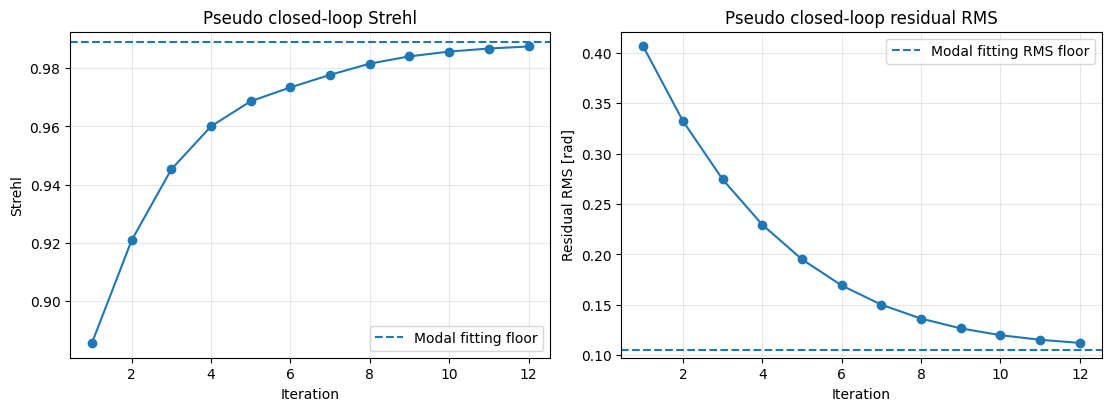

In [137]:
# ------------------------------------------------------------
# Closed-loop convergence plot
# ------------------------------------------------------------

iterations = [h["iteration"] for h in history_cl]
strehls = [h["strehl"] for h in history_cl]
residual_rms_values = [h["residual_rms"] for h in history_cl]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(iterations, strehls, "o-")
axes[0].axhline(
    strehl_ratio(np.nan_to_num(phase_fitting, nan=0.0), pupil_pw, pad_factor=PSF_PAD_FACTOR),
    linestyle="--",
    label="Modal fitting floor",
)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Strehl")
axes[0].set_title("Pseudo closed-loop Strehl")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(iterations, residual_rms_values, "o-")
axes[1].axhline(fitting_rms, linestyle="--", label="Modal fitting RMS floor")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Residual RMS [rad]")
axes[1].set_title("Pseudo closed-loop residual RMS")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()

## PSF and Strehl diagnostics

Strehl diagnostics:
  Input atmospheric phase       = 0.8370
  Modal fitting floor           = 0.9890
  One-shot noiseless PWFS       = 0.9887
  One-shot detector PWFS        = 0.9886
  Pseudo closed-loop PWFS       = 0.9875


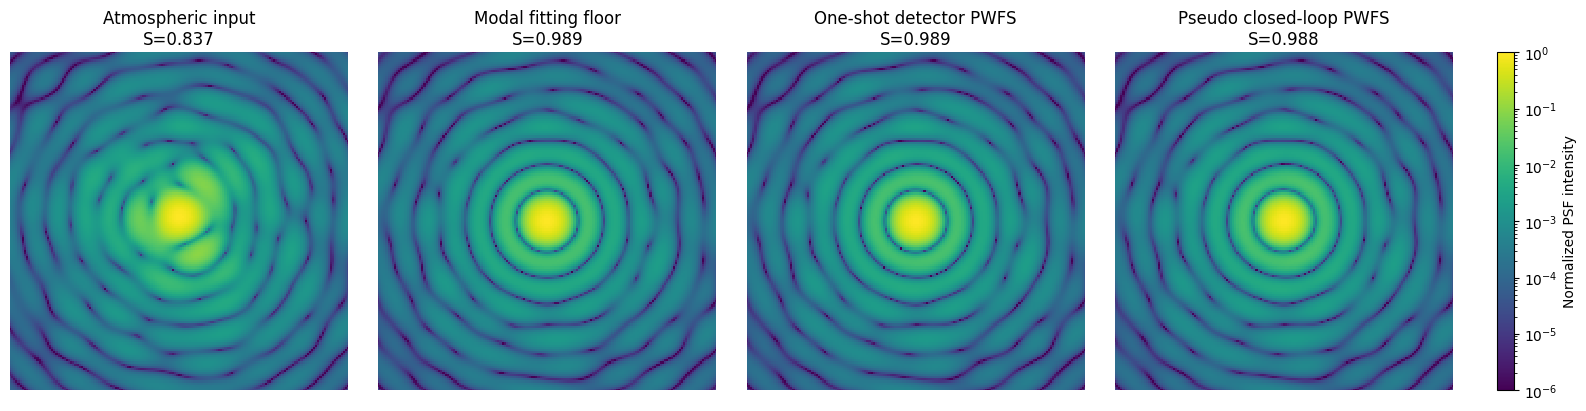

In [138]:
# -----------------------------
# Image-quality diagnostics
# -----------------------------

strehl_input = strehl_ratio(
    phase_atm,
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

strehl_fit_floor = strehl_ratio(
    np.nan_to_num(phase_fitting, nan=0.0),
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

strehl_one_shot_noiseless = strehl_ratio(
    np.nan_to_num(res_atm_noiseless, nan=0.0),
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

strehl_one_shot_detector = strehl_ratio(
    np.nan_to_num(res_atm_noisy, nan=0.0),
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

strehl_closed_loop = strehl_ratio(
    np.nan_to_num(residual_cl_map, nan=0.0),
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

print("Strehl diagnostics:")
print(f"  Input atmospheric phase       = {strehl_input:.4f}")
print(f"  Modal fitting floor           = {strehl_fit_floor:.4f}")
print(f"  One-shot noiseless PWFS       = {strehl_one_shot_noiseless:.4f}")
print(f"  One-shot detector PWFS        = {strehl_one_shot_detector:.4f}")
print(f"  Pseudo closed-loop PWFS       = {strehl_closed_loop:.4f}")

psf_input = compute_psf_from_phase(
    phase_atm,
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

psf_fit = compute_psf_from_phase(
    np.nan_to_num(phase_fitting, nan=0.0),
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

psf_one_shot = compute_psf_from_phase(
    np.nan_to_num(res_atm_noisy, nan=0.0),
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

psf_closed_loop = compute_psf_from_phase(
    np.nan_to_num(residual_cl_map, nan=0.0),
    pupil_pw,
    pad_factor=PSF_PAD_FACTOR,
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

for ax, psf, title in zip(
    axes,
    [psf_input, psf_fit, psf_one_shot, psf_closed_loop],
    [
        f"Atmospheric input\nS={strehl_input:.3f}",
        f"Modal fitting floor\nS={strehl_fit_floor:.3f}",
        f"One-shot detector PWFS\nS={strehl_one_shot_detector:.3f}",
        f"Pseudo closed-loop PWFS\nS={strehl_closed_loop:.3f}",
    ],
):
    psf_norm = psf / np.max(psf)

    im = ax.imshow(
        psf_norm,
        origin="lower",
        norm=LogNorm(vmin=1e-6, vmax=1.0),
        interpolation="nearest",
    )

    ax.set_title(title)
    cy, cx = np.array(psf.shape) // 2
    ax.set_xlim(cx - 80, cx + 80)
    ax.set_ylim(cy - 80, cy + 80)
    ax.axis("off")

fig.colorbar(
    im,
    ax=axes,
    fraction=0.025,
    pad=0.03,
    label="Normalized PSF intensity",
)

plt.show()

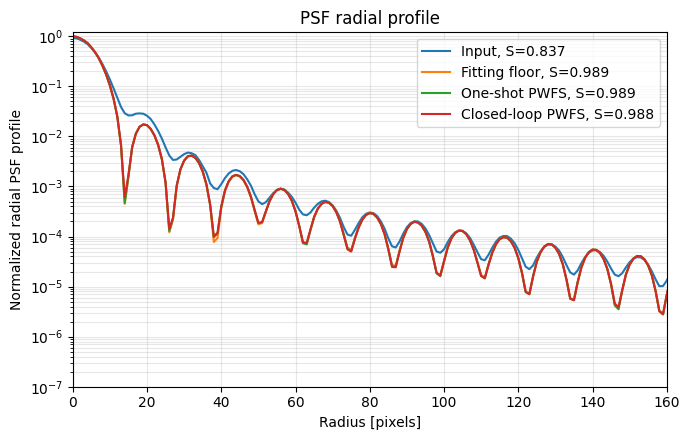

In [139]:
# -----------------------------
# PSF radial profiles
# -----------------------------

def radial_profile_local(psf):
    psf = np.asarray(psf, dtype=float)
    psf = psf / np.max(psf)

    ny, nx = psf.shape
    cy, cx = ny // 2, nx // 2

    yy, xx = np.indices(psf.shape)
    rr = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    rr_int = rr.astype(int)

    sums = np.bincount(rr_int.ravel(), weights=psf.ravel())
    counts = np.bincount(rr_int.ravel())
    profile = sums / np.maximum(counts, 1)

    radius = np.arange(len(profile))
    return radius, profile


r_input, p_input = radial_profile_local(psf_input)
r_fit, p_fit = radial_profile_local(psf_fit)
r_one, p_one = radial_profile_local(psf_one_shot)
r_cl, p_cl = radial_profile_local(psf_closed_loop)

plt.figure(figsize=(7, 4.5))
plt.semilogy(r_input, p_input, label=f"Input, S={strehl_input:.3f}")
plt.semilogy(r_fit, p_fit, label=f"Fitting floor, S={strehl_fit_floor:.3f}")
plt.semilogy(r_one, p_one, label=f"One-shot PWFS, S={strehl_one_shot_detector:.3f}")
plt.semilogy(r_cl, p_cl, label=f"Closed-loop PWFS, S={strehl_closed_loop:.3f}")

plt.xlim(0, 160)
plt.ylim(1e-7, 1.2)
plt.xlabel("Radius [pixels]")
plt.ylabel("Normalized radial PSF profile")
plt.title("PSF radial profile")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

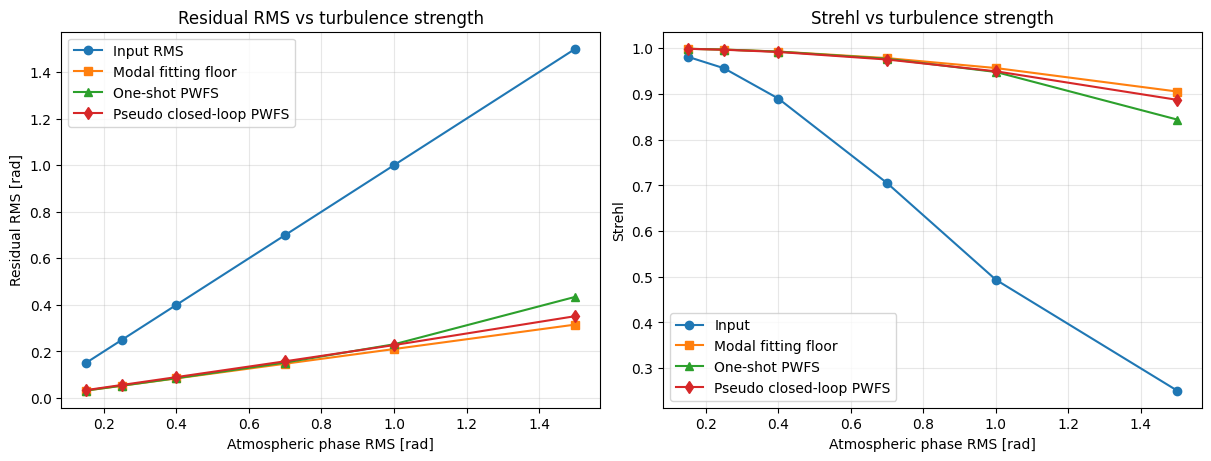

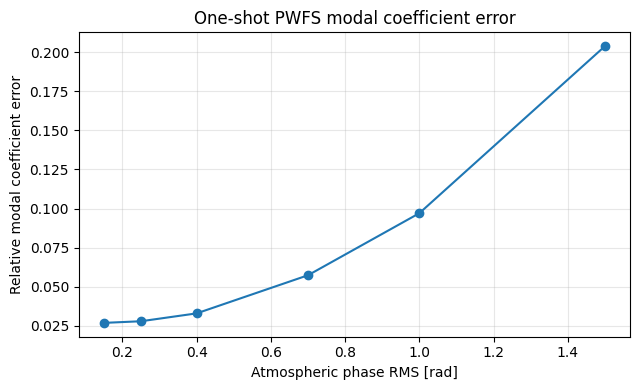

Atmospheric RMS scan:
---------------------
 atm RMS |  fit RMS | 1-shot RMS |   CL RMS |   fit S | 1-shot S |    CL S
----------------------------------------------------------------------------------
    0.15 |    0.032 |      0.032 |    0.034 |   0.999 |    0.999 |   0.999
    0.25 |    0.053 |      0.053 |    0.056 |   0.997 |    0.997 |   0.997
    0.40 |    0.084 |      0.085 |    0.090 |   0.993 |    0.993 |   0.992
    0.70 |    0.147 |      0.152 |    0.158 |   0.979 |    0.977 |   0.975
    1.00 |    0.210 |      0.231 |    0.227 |   0.957 |    0.948 |   0.950
    1.50 |    0.315 |      0.434 |    0.351 |   0.905 |    0.844 |   0.887


In [141]:
# ------------------------------------------------------------
# Atmospheric RMS scan: one-shot vs pseudo closed-loop PWFS
# ------------------------------------------------------------

ATM_RMS_SCAN = [0.15, 0.25, 0.40, 0.70, 1.00, 1.50]

SCAN_LOOP_ITERS = 12
SCAN_LOOP_GAIN = 0.20
SCAN_USE_DETECTOR_NOISE = False

# Use the same physical sampling as the main 08 phase screen.
delta_scan = DIAMETER_M / N_PUPIL

scan_results = []

for atm_rms_target in ATM_RMS_SCAN:
    # Generate one atmospheric phase screen with controlled RMS.
    phase_tmp_raw, _, _, _ = fourier_phase_screen(
        N=N_FFT,
        delta=delta_scan,
        r0=R0_M,
        L0=L0_M,
        diameter=DIAMETER_M,
        wavelength=WAVELENGTH_M,
        seed=ATM_SEED,
        target_rms_rad=atm_rms_target,
        normalize_rms=True,
    )

    phase_tmp = np.where(
        pupil_pw,
        np.nan_to_num(phase_tmp_raw, nan=0.0),
        0.0,
    )
    phase_tmp[pupil_pw] -= np.mean(phase_tmp[pupil_pw])

    # Project the atmospheric screen onto the controlled modal basis.
    coeff_tmp = project_phase_onto_modes(
        phase_tmp,
        modes_pw,
        mode_names,
        pupil_pw,
    )

    phase_modal_tmp = synthesize_from_coeffs(
        coeff_tmp,
        modes_pw,
        mode_names,
        pupil_pw,
    )

    phase_fitting_tmp, fitting_rms_tmp = residual_wavefront(
        phase_tmp,
        phase_modal_tmp,
        pupil_pw,
    )

    # -----------------------------
    # One-shot noiseless PWFS
    # -----------------------------

    s_tmp = pwfs_measurement_from_phase(
        phase=phase_tmp,
        pupil=pupil_pw,
        x=x_pw,
        y=y_pw,
        reference_signal=reference_pw,
        n_pupil=N_PUPIL,
        separation=PYRAMID_SEPARATION,
        central_obscuration=CENTRAL_OBSCURATION,
        pyramid_mask=pyramid_mask_pw,
        modulation_radius=MODULATION_RADIUS,
        n_modulation_points=N_MODULATION_POINTS,
    )

    rec_tmp = R_pw @ s_tmp

    phase_corr_tmp = synthesize_from_coeffs(
        rec_tmp,
        modes_pw,
        mode_names,
        pupil_pw,
    )

    res_one_shot_tmp, res_one_shot_rms_tmp = residual_wavefront(
        phase_tmp,
        phase_corr_tmp,
        pupil_pw,
    )

    # -----------------------------
    # Pseudo closed-loop PWFS
    # -----------------------------

    correction_cl_tmp, residual_cl_tmp, residual_cl_rms_tmp, history_cl_tmp = (
        pseudo_closed_loop_pwfs_08(
            phase_tmp,
            n_iter=SCAN_LOOP_ITERS,
            gain=SCAN_LOOP_GAIN,
            use_detector_noise=SCAN_USE_DETECTOR_NOISE,
            n_photons=N_PHOTONS,
            read_noise_e=READ_NOISE_E,
            seed=123,
        )
    )

    # -----------------------------
    # Strehl diagnostics
    # -----------------------------

    strehl_input_tmp = strehl_ratio(
        phase_tmp,
        pupil_pw,
        pad_factor=PSF_PAD_FACTOR,
    )

    strehl_floor_tmp = strehl_ratio(
        np.nan_to_num(phase_fitting_tmp, nan=0.0),
        pupil_pw,
        pad_factor=PSF_PAD_FACTOR,
    )

    strehl_one_shot_tmp = strehl_ratio(
        np.nan_to_num(res_one_shot_tmp, nan=0.0),
        pupil_pw,
        pad_factor=PSF_PAD_FACTOR,
    )

    strehl_cl_tmp = strehl_ratio(
        np.nan_to_num(residual_cl_tmp, nan=0.0),
        pupil_pw,
        pad_factor=PSF_PAD_FACTOR,
    )

    coeff_error_tmp = (
        np.linalg.norm(rec_tmp - coeff_tmp)
        / max(np.linalg.norm(coeff_tmp), 1e-12)
    )

    scan_results.append(
        {
            "atm_rms": atm_rms_target,
            "input_rms": rms(phase_tmp, pupil_pw),
            "fitting_rms": fitting_rms_tmp,
            "one_shot_rms": res_one_shot_rms_tmp,
            "closed_loop_rms": residual_cl_rms_tmp,
            "input_strehl": strehl_input_tmp,
            "fitting_strehl": strehl_floor_tmp,
            "one_shot_strehl": strehl_one_shot_tmp,
            "closed_loop_strehl": strehl_cl_tmp,
            "one_shot_coeff_error": coeff_error_tmp,
        }
    )


# Convert scan result to arrays for plotting.
atm_rms_arr = np.array([r["atm_rms"] for r in scan_results])

input_rms_arr = np.array([r["input_rms"] for r in scan_results])
fitting_rms_arr = np.array([r["fitting_rms"] for r in scan_results])
one_shot_rms_arr = np.array([r["one_shot_rms"] for r in scan_results])
closed_loop_rms_arr = np.array([r["closed_loop_rms"] for r in scan_results])

input_strehl_arr = np.array([r["input_strehl"] for r in scan_results])
fitting_strehl_arr = np.array([r["fitting_strehl"] for r in scan_results])
one_shot_strehl_arr = np.array([r["one_shot_strehl"] for r in scan_results])
closed_loop_strehl_arr = np.array([r["closed_loop_strehl"] for r in scan_results])

coeff_error_arr = np.array([r["one_shot_coeff_error"] for r in scan_results])


# -----------------------------
# Plot RMS and Strehl scan
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(atm_rms_arr, input_rms_arr, "o-", label="Input RMS")
axes[0].plot(atm_rms_arr, fitting_rms_arr, "s-", label="Modal fitting floor")
axes[0].plot(atm_rms_arr, one_shot_rms_arr, "^-", label="One-shot PWFS")
axes[0].plot(atm_rms_arr, closed_loop_rms_arr, "d-", label="Pseudo closed-loop PWFS")
axes[0].set_xlabel("Atmospheric phase RMS [rad]")
axes[0].set_ylabel("Residual RMS [rad]")
axes[0].set_title("Residual RMS vs turbulence strength")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(atm_rms_arr, input_strehl_arr, "o-", label="Input")
axes[1].plot(atm_rms_arr, fitting_strehl_arr, "s-", label="Modal fitting floor")
axes[1].plot(atm_rms_arr, one_shot_strehl_arr, "^-", label="One-shot PWFS")
axes[1].plot(atm_rms_arr, closed_loop_strehl_arr, "d-", label="Pseudo closed-loop PWFS")
axes[1].set_xlabel("Atmospheric phase RMS [rad]")
axes[1].set_ylabel("Strehl")
axes[1].set_title("Strehl vs turbulence strength")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()


# -----------------------------
# Modal coefficient error
# -----------------------------

plt.figure(figsize=(6.5, 4))
plt.plot(atm_rms_arr, coeff_error_arr, "o-")
plt.xlabel("Atmospheric phase RMS [rad]")
plt.ylabel("Relative modal coefficient error")
plt.title("One-shot PWFS modal coefficient error")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# Print compact table
# -----------------------------

print("Atmospheric RMS scan:")
print("---------------------")
print(
    f"{'atm RMS':>8s} | {'fit RMS':>8s} | {'1-shot RMS':>10s} | "
    f"{'CL RMS':>8s} | {'fit S':>7s} | {'1-shot S':>8s} | {'CL S':>7s}"
)
print("-" * 82)

for r in scan_results:
    print(
        f"{r['atm_rms']:8.2f} | "
        f"{r['fitting_rms']:8.3f} | "
        f"{r['one_shot_rms']:10.3f} | "
        f"{r['closed_loop_rms']:8.3f} | "
        f"{r['fitting_strehl']:7.3f} | "
        f"{r['one_shot_strehl']:8.3f} | "
        f"{r['closed_loop_strehl']:7.3f}"
    )

In [142]:
# ------------------------------------------------------------
# Optional frozen-flow temporal-loop settings
# 10 m telescope version
# ------------------------------------------------------------

from scipy.ndimage import shift as ndi_shift

RUN_FROZEN_FLOW_DEMO = True

# ------------------------------------------------------------
# Temporal loop
# ------------------------------------------------------------

LOOP_FREQUENCY_HZ = 500.0
DT = 1.0 / LOOP_FREQUENCY_HZ

# For D = 10 m, 40 frames at 500 Hz is only 80 ms.
# At 8 m/s, this moves the phase screen by 0.64 m = 0.064D.
# That is physically correct but visually slow.
# Use 100-150 steps if you want to see more frozen-flow evolution.
N_STEPS = 100

WIND_VX = 8.0   # m/s
WIND_VY = 3.0   # m/s

TEMPORAL_GAIN = 0.15
TEMPORAL_LEAK = 0.995
TEMPORAL_USE_DETECTOR_NOISE = False


# ------------------------------------------------------------
# Frozen-flow screen geometry
# ------------------------------------------------------------

SCREEN_FACTOR = 5
N_SCREEN = SCREEN_FACTOR * N_PUPIL

# Target RMS of the initial central pupil crop.
# This is again a controlled residual-like RMS, not raw 10 m seeing.
FROZEN_FLOW_TARGET_RMS_RAD = 0.70

delta_temporal = DIAMETER_M / N_PUPIL
SCREEN_SIDE_M = N_SCREEN * delta_temporal

assert N_SCREEN >= N_FFT, (
    "The frozen-flow screen must be at least as large as the PWFS FFT patch."
)

total_time_s = (N_STEPS - 1) * DT
wind_shift_x_m = WIND_VX * total_time_s
wind_shift_y_m = WIND_VY * total_time_s
wind_shift_total_m = np.sqrt(wind_shift_x_m**2 + wind_shift_y_m**2)

print("Frozen-flow setup:")
print(f"  telescope diameter D       = {DIAMETER_M:.3f} m")
print(f"  pixel scale                = {delta_temporal:.4e} m / pixel")
print(f"  PWFS FFT patch             = {N_FFT} px = {N_FFT * delta_temporal / DIAMETER_M:.2f} D")
print(f"  frozen-flow screen         = {N_SCREEN} px = {SCREEN_SIDE_M / DIAMETER_M:.2f} D")
print(f"  loop frequency             = {LOOP_FREQUENCY_HZ:.1f} Hz")
print(f"  number of frames           = {N_STEPS}")
print(f"  simulated duration         = {total_time_s * 1e3:.1f} ms")
print(f"  wind velocity              = ({WIND_VX:.1f}, {WIND_VY:.1f}) m/s")
print(f"  total wind shift           = {wind_shift_total_m:.3f} m = {wind_shift_total_m / DIAMETER_M:.3f} D")

Frozen-flow setup:
  telescope diameter D       = 10.000 m
  pixel scale                = 3.9062e-02 m / pixel
  PWFS FFT patch             = 768 px = 3.00 D
  frozen-flow screen         = 1280 px = 5.00 D
  loop frequency             = 500.0 Hz
  number of frames           = 100
  simulated duration         = 198.0 ms
  wind velocity              = (8.0, 3.0) m/s
  total wind shift           = 1.692 m = 0.169 D


In [143]:
# ------------------------------------------------------------
# Frozen-flow helper functions
# ------------------------------------------------------------

def center_crop_square(arr, out_size):
    """
    Extract a centered square patch from a larger 2D array.
    """
    arr = np.asarray(arr)
    ny, nx = arr.shape

    if out_size > ny or out_size > nx:
        raise ValueError("out_size must be smaller than the input array dimensions.")

    y0 = ny // 2 - out_size // 2
    x0 = nx // 2 - out_size // 2

    return arr[y0:y0 + out_size, x0:x0 + out_size]


def frozen_flow_phase_at_time(
    phase_full,
    time_s,
    wind_vx,
    wind_vy,
    delta,
    patch_size,
    pupil_mask,
):
    """
    Shift a large frozen-flow phase screen and extract the central PWFS patch.
    """
    shift_y = wind_vy * time_s / delta
    shift_x = wind_vx * time_s / delta

    phase_shifted_full = ndi_shift(
        phase_full,
        shift=(shift_y, shift_x),
        order=1,
        mode="wrap",
    )

    phase_patch = center_crop_square(
        phase_shifted_full,
        patch_size,
    )

    phase_pupil = np.where(
        pupil_mask,
        phase_patch,
        0.0,
    )

    phase_pupil[pupil_mask] -= np.mean(phase_pupil[pupil_mask])

    return phase_pupil, phase_patch


def measure_pwfs_residual_signal_08(
    residual_phase,
    use_detector_noise=False,
    seed=None,
):
    """
    Measure a residual phase with the 08 PWFS settings.
    """
    if use_detector_noise:
        return pwfs_detector_measurement_from_phase(
            phase=residual_phase,
            pupil=pupil_pw,
            x=x_pw,
            y=y_pw,
            reference_signal=reference_pw,
            n_photons=N_PHOTONS,
            read_noise_e=READ_NOISE_E,
            seed=seed,
            n_pupil=N_PUPIL,
            separation=PYRAMID_SEPARATION,
            central_obscuration=CENTRAL_OBSCURATION,
            pyramid_mask=pyramid_mask_pw,
            modulation_radius=MODULATION_RADIUS,
            n_modulation_points=N_MODULATION_POINTS,
        )

    return pwfs_measurement_from_phase(
        phase=residual_phase,
        pupil=pupil_pw,
        x=x_pw,
        y=y_pw,
        reference_signal=reference_pw,
        n_pupil=N_PUPIL,
        separation=PYRAMID_SEPARATION,
        central_obscuration=CENTRAL_OBSCURATION,
        pyramid_mask=pyramid_mask_pw,
        modulation_radius=MODULATION_RADIUS,
        n_modulation_points=N_MODULATION_POINTS,
    )

In [144]:
# ------------------------------------------------------------
# Generate 5D frozen-flow phase screen
# ------------------------------------------------------------

phase0_full_raw, _, _, _ = fourier_phase_screen(
    N=N_SCREEN,
    delta=delta_temporal,
    r0=R0_M,
    L0=L0_M,
    diameter=SCREEN_SIDE_M,
    wavelength=WAVELENGTH_M,
    seed=ATM_SEED,
    target_rms_rad=FROZEN_FLOW_TARGET_RMS_RAD,
    normalize_rms=True,
    mask_output=False,
)

phase0_full = phase0_full_raw.copy()
phase0_full -= np.mean(phase0_full)

# Rescale the full screen so that the initial central pupil crop has the target RMS.
phase_initial, phase_patch_initial = frozen_flow_phase_at_time(
    phase0_full,
    time_s=0.0,
    wind_vx=WIND_VX,
    wind_vy=WIND_VY,
    delta=delta_temporal,
    patch_size=N_FFT,
    pupil_mask=pupil_pw,
)

initial_crop_rms = rms(phase_initial, pupil_pw)

phase0_full *= FROZEN_FLOW_TARGET_RMS_RAD / max(initial_crop_rms, 1e-12)

phase_initial, phase_patch_initial = frozen_flow_phase_at_time(
    phase0_full,
    time_s=0.0,
    wind_vx=WIND_VX,
    wind_vy=WIND_VY,
    delta=delta_temporal,
    patch_size=N_FFT,
    pupil_mask=pupil_pw,
)

print("Generated frozen-flow phase screen:")
print(f"  full screen shape           = {phase0_full.shape}")
print(f"  PWFS patch shape            = {phase_patch_initial.shape}")
print(f"  initial pupil RMS           = {rms(phase_initial, pupil_pw):.4e} rad")
print(f"  target initial pupil RMS    = {FROZEN_FLOW_TARGET_RMS_RAD:.4e} rad")

Generated frozen-flow phase screen:
  full screen shape           = (1280, 1280)
  PWFS patch shape            = (768, 768)
  initial pupil RMS           = 7.0000e-01 rad
  target initial pupil RMS    = 7.0000e-01 rad


In [145]:
# ------------------------------------------------------------
# Run toy frozen-flow temporal PWFS loop
# ------------------------------------------------------------

if RUN_FROZEN_FLOW_DEMO:
    command_coeffs = np.zeros(len(mode_names))

    temporal_history = []
    rng_temporal = np.random.default_rng(456)

    for k in range(N_STEPS):
        t = k * DT

        # Frozen-flow atmospheric phase at the current time.
        phase_t, _ = frozen_flow_phase_at_time(
            phase0_full,
            time_s=t,
            wind_vx=WIND_VX,
            wind_vy=WIND_VY,
            delta=delta_temporal,
            patch_size=N_FFT,
            pupil_mask=pupil_pw,
        )

        # Previous command is applied to the current frame.
        # This creates a one-frame command delay.
        correction_phase = synthesize_from_coeffs(
            command_coeffs,
            modes_pw,
            mode_names,
            pupil_pw,
        )

        residual_before = phase_t - correction_phase
        residual_before[~pupil_pw] = 0.0
        residual_before[pupil_pw] -= np.mean(residual_before[pupil_pw])

        # WFS measures the current residual.
        noise_seed = int(rng_temporal.integers(0, 2**31 - 1))

        s_t = measure_pwfs_residual_signal_08(
            residual_before,
            use_detector_noise=TEMPORAL_USE_DETECTOR_NOISE,
            seed=noise_seed,
        )

        coeff_est_t = R_pw @ s_t

        # Integrator update.
        # This updated command affects the next frame.
        command_coeffs = (
            TEMPORAL_LEAK * command_coeffs
            + TEMPORAL_GAIN * coeff_est_t
        )

        # Instantaneous modal fitting floor for the current atmospheric phase.
        coeff_true_t = project_phase_onto_modes(
            phase_t,
            modes_pw,
            mode_names,
            pupil_pw,
        )

        phase_modal_t = synthesize_from_coeffs(
            coeff_true_t,
            modes_pw,
            mode_names,
            pupil_pw,
        )

        fitting_residual_t, fitting_rms_t = residual_wavefront(
            phase_t,
            phase_modal_t,
            pupil_pw,
        )

        input_rms_t = rms(phase_t, pupil_pw)
        residual_rms_t = rms(residual_before, pupil_pw)

        input_strehl_t = strehl_ratio(
            phase_t,
            pupil_pw,
            pad_factor=PSF_PAD_FACTOR,
        )

        fitting_strehl_t = strehl_ratio(
            np.nan_to_num(fitting_residual_t, nan=0.0),
            pupil_pw,
            pad_factor=PSF_PAD_FACTOR,
        )

        residual_strehl_t = strehl_ratio(
            residual_before,
            pupil_pw,
            pad_factor=PSF_PAD_FACTOR,
        )

        temporal_history.append(
            {
                "step": k,
                "time": t,
                "input_rms": input_rms_t,
                "fitting_rms": fitting_rms_t,
                "residual_rms": residual_rms_t,
                "input_strehl": input_strehl_t,
                "fitting_strehl": fitting_strehl_t,
                "residual_strehl": residual_strehl_t,
                "command_norm": np.linalg.norm(command_coeffs),
                "coeff_est_norm": np.linalg.norm(coeff_est_t),
            }
        )

    print(f"Temporal loop finished with {len(temporal_history)} frames.")

Temporal loop finished with 100 frames.


In [146]:
# ------------------------------------------------------------
# Convert temporal history to arrays
# ------------------------------------------------------------

times = np.array([h["time"] for h in temporal_history])

input_rms_time = np.array([h["input_rms"] for h in temporal_history])
fitting_rms_time = np.array([h["fitting_rms"] for h in temporal_history])
residual_rms_time = np.array([h["residual_rms"] for h in temporal_history])

input_strehl_time = np.array([h["input_strehl"] for h in temporal_history])
fitting_strehl_time = np.array([h["fitting_strehl"] for h in temporal_history])
residual_strehl_time = np.array([h["residual_strehl"] for h in temporal_history])

command_norm_time = np.array([h["command_norm"] for h in temporal_history])
coeff_est_norm_time = np.array([h["coeff_est_norm"] for h in temporal_history])

print("Temporal-loop sanity check:")
print(f"  input RMS min / median / max     = {input_rms_time.min():.3f} / {np.median(input_rms_time):.3f} / {input_rms_time.max():.3f} rad")
print(f"  residual RMS min / median / max  = {residual_rms_time.min():.3f} / {np.median(residual_rms_time):.3f} / {residual_rms_time.max():.3f} rad")
print(f"  final residual Strehl            = {residual_strehl_time[-1]:.4f}")

Temporal-loop sanity check:
  input RMS min / median / max     = 0.638 / 0.669 / 0.700 rad
  residual RMS min / median / max  = 0.205 / 0.217 / 0.700 rad
  final residual Strehl            = 0.9586


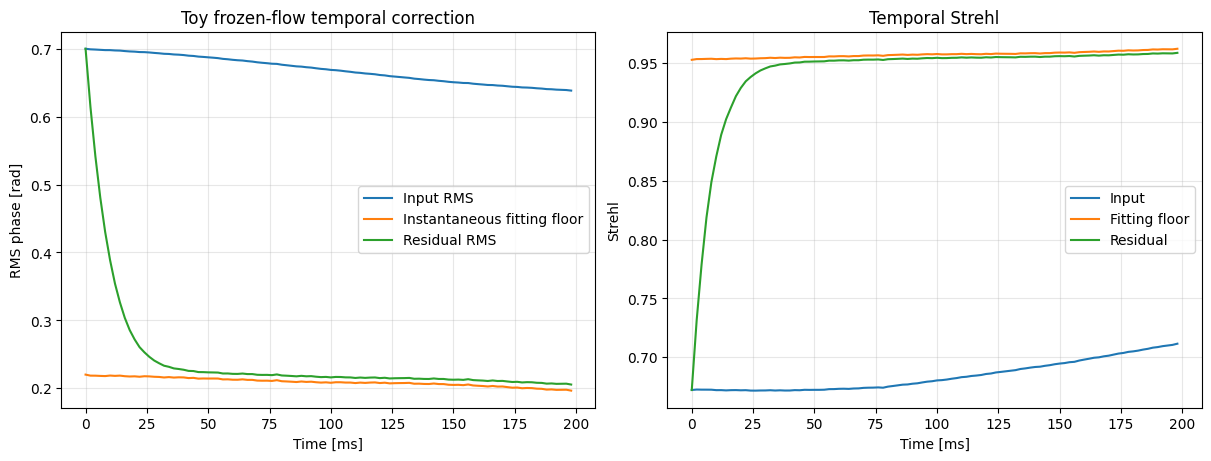

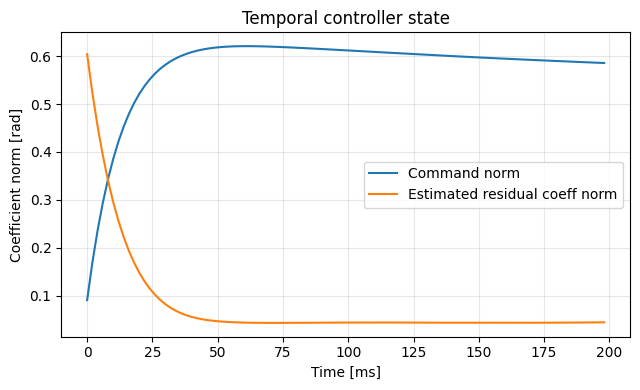

Toy frozen-flow temporal PWFS loop:
-----------------------------------
  frozen-flow screen size     = 5.0 D
  loop frequency              = 500.0 Hz
  wind velocity               = (8.0, 3.0) m/s
  temporal gain               = 0.15
  detector noise enabled      = False

  initial input RMS           = 7.0000e-01 rad
  final input RMS             = 6.3839e-01 rad
  initial residual RMS        = 7.0000e-01 rad
  final residual RMS          = 2.0548e-01 rad
  final fitting RMS           = 1.9651e-01 rad

  initial residual Strehl     = 0.6721
  final residual Strehl       = 0.9586


In [147]:
# ------------------------------------------------------------
# Plot toy frozen-flow temporal PWFS loop
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(times * 1e3, input_rms_time, label="Input RMS")
axes[0].plot(times * 1e3, fitting_rms_time, label="Instantaneous fitting floor")
axes[0].plot(times * 1e3, residual_rms_time, label="Residual RMS")
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel("RMS phase [rad]")
axes[0].set_title("Toy frozen-flow temporal correction")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(times * 1e3, input_strehl_time, label="Input")
axes[1].plot(times * 1e3, fitting_strehl_time, label="Fitting floor")
axes[1].plot(times * 1e3, residual_strehl_time, label="Residual")
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("Strehl")
axes[1].set_title("Temporal Strehl")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()


plt.figure(figsize=(6.5, 4))
plt.plot(times * 1e3, command_norm_time, label="Command norm")
plt.plot(times * 1e3, coeff_est_norm_time, label="Estimated residual coeff norm")
plt.xlabel("Time [ms]")
plt.ylabel("Coefficient norm [rad]")
plt.title("Temporal controller state")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


print("Toy frozen-flow temporal PWFS loop:")
print("-----------------------------------")
print(f"  frozen-flow screen size     = {SCREEN_FACTOR:.1f} D")
print(f"  loop frequency              = {LOOP_FREQUENCY_HZ:.1f} Hz")
print(f"  wind velocity               = ({WIND_VX:.1f}, {WIND_VY:.1f}) m/s")
print(f"  temporal gain               = {TEMPORAL_GAIN:.2f}")
print(f"  detector noise enabled      = {TEMPORAL_USE_DETECTOR_NOISE}")
print()
print(f"  initial input RMS           = {input_rms_time[0]:.4e} rad")
print(f"  final input RMS             = {input_rms_time[-1]:.4e} rad")
print(f"  initial residual RMS        = {residual_rms_time[0]:.4e} rad")
print(f"  final residual RMS          = {residual_rms_time[-1]:.4e} rad")
print(f"  final fitting RMS           = {fitting_rms_time[-1]:.4e} rad")
print()
print(f"  initial residual Strehl     = {residual_strehl_time[0]:.4f}")
print(f"  final residual Strehl       = {residual_strehl_time[-1]:.4f}")

### PWFS modulation and staged loop closing

The modulation radius controls how far the focal-plane PSF is moved around the pyramid tip. In a real PWFS this is usually implemented with a fast steering/modulation mirror. Larger modulation increases the linear range and makes loop acquisition more robust, but reduces the small-signal sensitivity. Therefore, realistic PWFS loop closing often starts with large modulation, low gain, and a limited number of modes, then progressively reduces modulation and increases the controlled modal space as the residual wavefront becomes smaller.

In [148]:
# ------------------------------------------------------------
# Staged PWFS loop-closing schedule
# ------------------------------------------------------------

RUN_STAGED_LOOP_DEMO = True

# The idea:
#   Stage 1: robust acquisition-like stage
#            large modulation, low gain, low-order modes only
#   Stage 2: intermediate correction
#            medium modulation, more modes
#   Stage 3: high-sensitivity residual regime
#            smaller modulation, more modes

STAGED_LOOP_SCHEDULE = [
    {
        "name": "Stage 1: acquisition / robust low-order",
        "start_frame": 0,
        "end_frame": 30,
        "modulation_radius": 3.0,
        "gain": 0.08,
        "n_active_modes": min(15, len(mode_names)),
        "rcond": 5e-3,
    },
    {
        "name": "Stage 2: intermediate correction",
        "start_frame": 30,
        "end_frame": 70,
        "modulation_radius": 1.5,
        "gain": 0.12,
        "n_active_modes": min(30, len(mode_names)),
        "rcond": 3e-3,
    },
    {
        "name": "Stage 3: high-sensitivity residual regime",
        "start_frame": 70,
        "end_frame": N_STEPS,
        "modulation_radius": 0.7,
        "gain": 0.15,
        "n_active_modes": min(len(mode_names), N_MODES),
        "rcond": 2e-3,
    },
]

# Use the same frozen-flow temporal settings as before.
STAGED_TEMPORAL_LEAK = 0.995
STAGED_USE_DETECTOR_NOISE = False

for s in STAGED_LOOP_SCHEDULE:
    print(
        f"{s['name']}: "
        f"frames {s['start_frame']}–{s['end_frame'] - 1}, "
        f"mod={s['modulation_radius']:.2f}, "
        f"gain={s['gain']:.2f}, "
        f"active modes={s['n_active_modes']}, "
        f"rcond={s['rcond']:.1e}"
    )

Stage 1: acquisition / robust low-order: frames 0–29, mod=3.00, gain=0.08, active modes=15, rcond=5.0e-03
Stage 2: intermediate correction: frames 30–69, mod=1.50, gain=0.12, active modes=30, rcond=3.0e-03
Stage 3: high-sensitivity residual regime: frames 70–99, mod=0.70, gain=0.15, active modes=50, rcond=2.0e-03


In [149]:
# ------------------------------------------------------------
# Helper functions for staged loop closing
# ------------------------------------------------------------

def make_tsvd_reconstructor_local(A, rcond=1e-3):
    """
    Build a truncated-SVD reconstructor R such that coeffs = R @ signal.
    """
    U, S, Vt = np.linalg.svd(A, full_matrices=False)

    cutoff = rcond * np.max(S)
    keep = S > cutoff

    Sinv = np.zeros_like(S)
    Sinv[keep] = 1.0 / S[keep]

    R = (Vt.T * Sinv) @ U.T

    return R, S, keep


def get_stage_for_frame(frame_index, schedule):
    """
    Return the active staged-loop dictionary for a given frame index.
    """
    for stage in schedule:
        if stage["start_frame"] <= frame_index < stage["end_frame"]:
            return stage

    return schedule[-1]

In [150]:
# ------------------------------------------------------------
# Calibrate one PWFS reconstructor per staged-loop phase
# ------------------------------------------------------------

stage_calibrations = {}

if RUN_STAGED_LOOP_DEMO:
    for stage in STAGED_LOOP_SCHEDULE:
        mod = stage["modulation_radius"]
        rcond_stage = stage["rcond"]

        print(f"Calibrating PWFS interaction matrix for modulation radius = {mod:.2f} ...")

        A_stage, names_stage, reference_stage = calibrate_pwfs_interaction_matrix(
            modes_pw,
            pupil_pw,
            x_pw,
            y_pw,
            calibration_amplitude=CALIB_AMP,
            n_pupil=N_PUPIL,
            separation=PYRAMID_SEPARATION,
            central_obscuration=CENTRAL_OBSCURATION,
            pyramid_mask=pyramid_mask_pw,
            modulation_radius=mod,
            n_modulation_points=N_MODULATION_POINTS,
            differential=True,
        )

        R_stage, S_stage, keep_stage = make_tsvd_reconstructor_local(
            A_stage,
            rcond=rcond_stage,
        )

        stage_calibrations[mod] = {
            "A": A_stage,
            "R": R_stage,
            "S": S_stage,
            "keep": keep_stage,
            "reference": reference_stage,
            "names": names_stage,
        }

        cond_stage = S_stage[0] / S_stage[-1]
        print(
            f"  signal length = {A_stage.shape[0]}, "
            f"modes = {A_stage.shape[1]}, "
            f"kept singular values = {np.sum(keep_stage)}/{len(S_stage)}, "
            f"condition number = {cond_stage:.3e}"
        )

Calibrating PWFS interaction matrix for modulation radius = 3.00 ...
  signal length = 102862, modes = 50, kept singular values = 50/50, condition number = 5.569e+00
Calibrating PWFS interaction matrix for modulation radius = 1.50 ...
  signal length = 102862, modes = 50, kept singular values = 50/50, condition number = 6.878e+00
Calibrating PWFS interaction matrix for modulation radius = 0.70 ...
  signal length = 102862, modes = 50, kept singular values = 50/50, condition number = 5.310e+00


In [151]:
# ------------------------------------------------------------
# Measurement helper for staged-loop PWFS
# ------------------------------------------------------------

def measure_staged_pwfs_signal_08(
    residual_phase,
    stage,
    calibration,
    use_detector_noise=False,
    seed=None,
):
    """
    Measure residual phase using the modulation radius and reference signal
    associated with the current staged-loop phase.
    """
    mod = stage["modulation_radius"]
    reference_signal_stage = calibration["reference"]

    if use_detector_noise:
        return pwfs_detector_measurement_from_phase(
            phase=residual_phase,
            pupil=pupil_pw,
            x=x_pw,
            y=y_pw,
            reference_signal=reference_signal_stage,
            n_photons=N_PHOTONS,
            read_noise_e=READ_NOISE_E,
            seed=seed,
            n_pupil=N_PUPIL,
            separation=PYRAMID_SEPARATION,
            central_obscuration=CENTRAL_OBSCURATION,
            pyramid_mask=pyramid_mask_pw,
            modulation_radius=mod,
            n_modulation_points=N_MODULATION_POINTS,
        )

    return pwfs_measurement_from_phase(
        phase=residual_phase,
        pupil=pupil_pw,
        x=x_pw,
        y=y_pw,
        reference_signal=reference_signal_stage,
        n_pupil=N_PUPIL,
        separation=PYRAMID_SEPARATION,
        central_obscuration=CENTRAL_OBSCURATION,
        pyramid_mask=pyramid_mask_pw,
        modulation_radius=mod,
        n_modulation_points=N_MODULATION_POINTS,
    )

In [152]:
# ------------------------------------------------------------
# Run staged frozen-flow PWFS loop
# ------------------------------------------------------------

if RUN_STAGED_LOOP_DEMO:
    staged_command_coeffs = np.zeros(len(mode_names))
    staged_history = []

    rng_staged = np.random.default_rng(789)

    for k in range(N_STEPS):
        t = k * DT

        stage = get_stage_for_frame(k, STAGED_LOOP_SCHEDULE)
        mod = stage["modulation_radius"]
        gain = stage["gain"]
        n_active = stage["n_active_modes"]

        calibration = stage_calibrations[mod]
        R_stage = calibration["R"]

        # Frozen-flow atmospheric phase at the current time.
        phase_t, _ = frozen_flow_phase_at_time(
            phase0_full,
            time_s=t,
            wind_vx=WIND_VX,
            wind_vy=WIND_VY,
            delta=delta_temporal,
            patch_size=N_FFT,
            pupil_mask=pupil_pw,
        )

        # Previous command is applied to current frame.
        correction_phase = synthesize_from_coeffs(
            staged_command_coeffs,
            modes_pw,
            mode_names,
            pupil_pw,
        )

        residual_before = phase_t - correction_phase
        residual_before[~pupil_pw] = 0.0
        residual_before[pupil_pw] -= np.mean(residual_before[pupil_pw])

        # WFS measurement with current stage modulation/reference.
        noise_seed = int(rng_staged.integers(0, 2**31 - 1))

        s_t = measure_staged_pwfs_signal_08(
            residual_phase=residual_before,
            stage=stage,
            calibration=calibration,
            use_detector_noise=STAGED_USE_DETECTOR_NOISE,
            seed=noise_seed,
        )

        coeff_est_t = R_stage @ s_t

        # Only update the active controlled modes in this stage.
        coeff_update = np.zeros_like(staged_command_coeffs)
        coeff_update[:n_active] = coeff_est_t[:n_active]

        staged_command_coeffs = (
            STAGED_TEMPORAL_LEAK * staged_command_coeffs
            + gain * coeff_update
        )

        # Optional: keep not-yet-active high-order modes exactly zero.
        # This makes the staged-mode transition easier to interpret.
        staged_command_coeffs[n_active:] = 0.0

        # Instantaneous fitting floor.
        coeff_true_t = project_phase_onto_modes(
            phase_t,
            modes_pw,
            mode_names,
            pupil_pw,
        )

        phase_modal_t = synthesize_from_coeffs(
            coeff_true_t,
            modes_pw,
            mode_names,
            pupil_pw,
        )

        fitting_residual_t, fitting_rms_t = residual_wavefront(
            phase_t,
            phase_modal_t,
            pupil_pw,
        )

        input_rms_t = rms(phase_t, pupil_pw)
        residual_rms_t = rms(residual_before, pupil_pw)

        input_strehl_t = strehl_ratio(
            phase_t,
            pupil_pw,
            pad_factor=PSF_PAD_FACTOR,
        )

        fitting_strehl_t = strehl_ratio(
            np.nan_to_num(fitting_residual_t, nan=0.0),
            pupil_pw,
            pad_factor=PSF_PAD_FACTOR,
        )

        residual_strehl_t = strehl_ratio(
            residual_before,
            pupil_pw,
            pad_factor=PSF_PAD_FACTOR,
        )

        staged_history.append(
            {
                "step": k,
                "time": t,
                "stage_name": stage["name"],
                "modulation_radius": mod,
                "gain": gain,
                "n_active_modes": n_active,
                "input_rms": input_rms_t,
                "fitting_rms": fitting_rms_t,
                "residual_rms": residual_rms_t,
                "input_strehl": input_strehl_t,
                "fitting_strehl": fitting_strehl_t,
                "residual_strehl": residual_strehl_t,
                "command_norm": np.linalg.norm(staged_command_coeffs),
                "coeff_est_norm": np.linalg.norm(coeff_est_t),
            }
        )

    print(f"Staged temporal loop finished with {len(staged_history)} frames.")

Staged temporal loop finished with 100 frames.


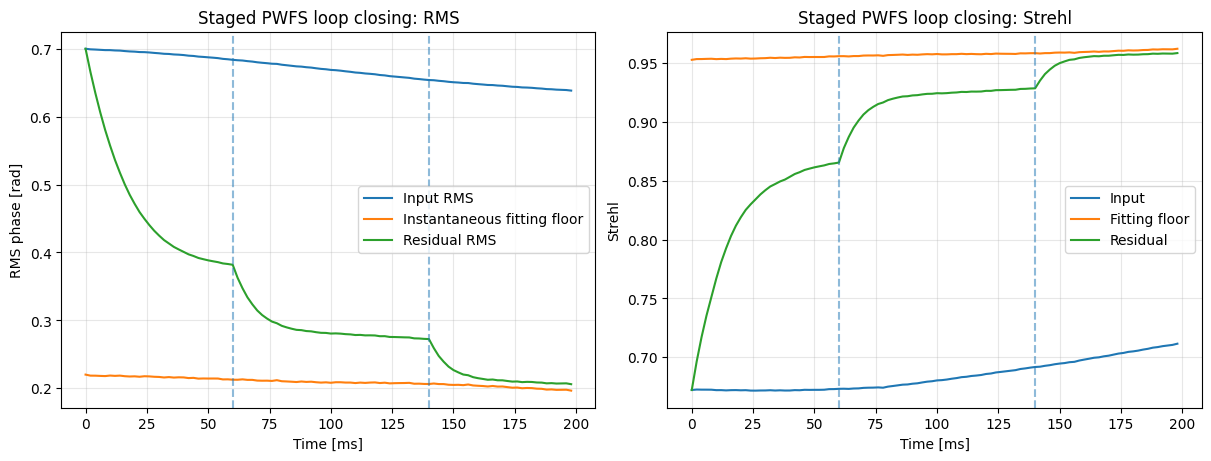

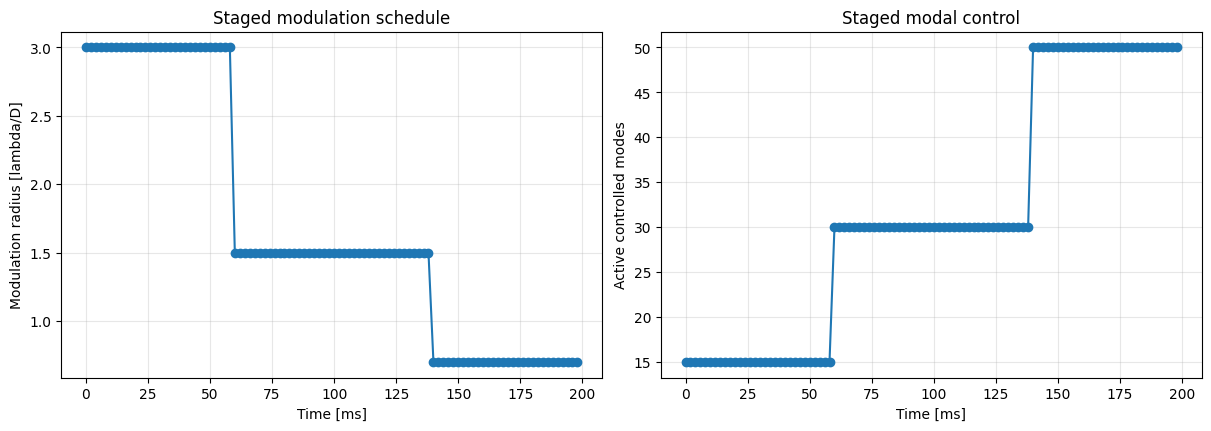

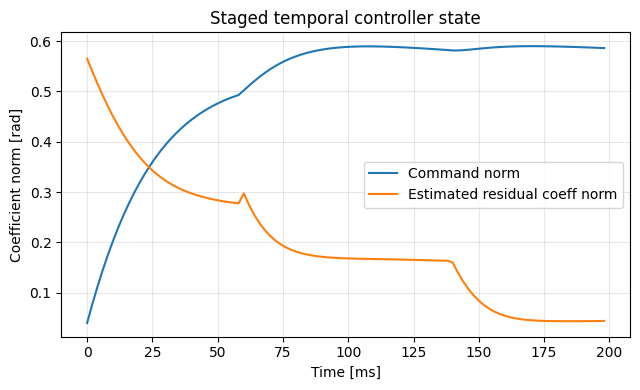

Staged PWFS loop-closing summary:
---------------------------------
  initial residual RMS       = 7.0000e-01 rad
  final residual RMS         = 2.0599e-01 rad
  final fitting RMS          = 1.9651e-01 rad
  initial residual Strehl    = 0.6721
  final residual Strehl      = 0.9584
  final modulation radius    = 0.70 lambda/D
  final active modes         = 50


In [153]:
# ------------------------------------------------------------
# Plot staged frozen-flow PWFS loop result
# ------------------------------------------------------------

staged_times = np.array([h["time"] for h in staged_history])

staged_input_rms = np.array([h["input_rms"] for h in staged_history])
staged_fitting_rms = np.array([h["fitting_rms"] for h in staged_history])
staged_residual_rms = np.array([h["residual_rms"] for h in staged_history])

staged_input_strehl = np.array([h["input_strehl"] for h in staged_history])
staged_fitting_strehl = np.array([h["fitting_strehl"] for h in staged_history])
staged_residual_strehl = np.array([h["residual_strehl"] for h in staged_history])

staged_command_norm = np.array([h["command_norm"] for h in staged_history])
staged_coeff_est_norm = np.array([h["coeff_est_norm"] for h in staged_history])
staged_modulation = np.array([h["modulation_radius"] for h in staged_history])
staged_active_modes = np.array([h["n_active_modes"] for h in staged_history])


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(staged_times * 1e3, staged_input_rms, label="Input RMS")
axes[0].plot(staged_times * 1e3, staged_fitting_rms, label="Instantaneous fitting floor")
axes[0].plot(staged_times * 1e3, staged_residual_rms, label="Residual RMS")
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel("RMS phase [rad]")
axes[0].set_title("Staged PWFS loop closing: RMS")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(staged_times * 1e3, staged_input_strehl, label="Input")
axes[1].plot(staged_times * 1e3, staged_fitting_strehl, label="Fitting floor")
axes[1].plot(staged_times * 1e3, staged_residual_strehl, label="Residual")
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("Strehl")
axes[1].set_title("Staged PWFS loop closing: Strehl")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Mark stage transitions.
for ax in axes:
    for stage in STAGED_LOOP_SCHEDULE[1:]:
        t_transition = stage["start_frame"] * DT * 1e3
        ax.axvline(t_transition, linestyle="--", alpha=0.5)

plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

axes[0].plot(staged_times * 1e3, staged_modulation, "o-")
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel("Modulation radius [lambda/D]")
axes[0].set_title("Staged modulation schedule")
axes[0].grid(True, alpha=0.3)

axes[1].plot(staged_times * 1e3, staged_active_modes, "o-")
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("Active controlled modes")
axes[1].set_title("Staged modal control")
axes[1].grid(True, alpha=0.3)

plt.show()


plt.figure(figsize=(6.5, 4))
plt.plot(staged_times * 1e3, staged_command_norm, label="Command norm")
plt.plot(staged_times * 1e3, staged_coeff_est_norm, label="Estimated residual coeff norm")
plt.xlabel("Time [ms]")
plt.ylabel("Coefficient norm [rad]")
plt.title("Staged temporal controller state")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


print("Staged PWFS loop-closing summary:")
print("---------------------------------")
print(f"  initial residual RMS       = {staged_residual_rms[0]:.4e} rad")
print(f"  final residual RMS         = {staged_residual_rms[-1]:.4e} rad")
print(f"  final fitting RMS          = {staged_fitting_rms[-1]:.4e} rad")
print(f"  initial residual Strehl    = {staged_residual_strehl[0]:.4f}")
print(f"  final residual Strehl      = {staged_residual_strehl[-1]:.4f}")
print(f"  final modulation radius    = {staged_modulation[-1]:.2f} lambda/D")
print(f"  final active modes         = {staged_active_modes[-1]}")

## Optional detector-noise scan

In [154]:
# Set this to True when you want a repeated noisy detector test.
RUN_DETECTOR_NOISE_SCAN = False

if RUN_DETECTOR_NOISE_SCAN:
    photon_levels = [1e4, 3e4, 1e5, 3e5, 1e6]
    n_trials = 5

    results = []
    for photons in photon_levels:
        rms_trials = []
        coeff_trials = []
        for trial in range(n_trials):
            s_trial = pwfs_detector_measurement_from_phase(
                phase_atm,
                pupil=pupil_pw,
                x=x_pw,
                y=y_pw,
                reference_signal=reference_pw,
                n_photons=photons,
                read_noise_e=READ_NOISE_E,
                seed=1000 + trial,
                n_pupil=N_PUPIL,
                separation=PYRAMID_SEPARATION,
                central_obscuration=CENTRAL_OBSCURATION,
                pyramid_mask=pyramid_mask_pw,
                modulation_radius=MODULATION_RADIUS,
                n_modulation_points=N_MODULATION_POINTS,
            )

            c_trial = R_pw @ s_trial
            phase_corr_trial = synthesize_from_coeffs(c_trial, modes_pw, mode_names, pupil_pw)
            res_trial, res_rms_trial = residual_wavefront(phase_atm, phase_corr_trial, pupil_pw)

            rms_trials.append(res_rms_trial)
            coeff_trials.append(np.linalg.norm(c_trial - coeff_atm) / np.linalg.norm(coeff_atm))

        results.append((photons, np.mean(rms_trials), np.std(rms_trials), np.mean(coeff_trials)))

    results = np.array(results, dtype=float)

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(results[:, 0], results[:, 1], yerr=results[:, 2], marker="o", capsize=3)
    plt.axhline(fitting_rms, linestyle="--", label="modal fitting floor")
    plt.xscale("log")
    plt.xlabel("Total photons on detector")
    plt.ylabel("Atmospheric residual RMS [rad]")
    plt.title("PWFS detector-level photon-noise scan")
    plt.grid(True, alpha=0.3, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Detector-noise scan skipped. Set RUN_DETECTOR_NOISE_SCAN = True to run it.")

Detector-noise scan skipped. Set RUN_DETECTOR_NOISE_SCAN = True to run it.


## Summary

This notebook is now detector-level in the PWFS sense: the science measurement is made from a pixelated noisy detector image, not from an abstract signal perturbation. The calibration remains noiseless/high-SNR, which is the intended setup for an interaction-matrix AO simulator.

The atmospheric input contains spatial frequencies outside the calibrated modal space; therefore the fitting-error floor is the physically relevant lower bound for this finite-mode reconstructor.

In [155]:
# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

summary = {
    # Main configuration
    "telescope_diameter_m": DIAMETER_M,
    "n_pupil": N_PUPIL,
    "n_fft": N_FFT,
    "n_modes": len(mode_names),
    "pwfs_signal_length": A_pw.shape[0],
    "main_modulation_radius_lambda_over_D": MODULATION_RADIUS,
    "main_condition_number": cond_pw,

    # Static atmospheric benchmark
    "atmospheric_input_rms_rad": rms(phase_atm, pupil_pw),
    "static_fitting_error_floor_rad": fitting_rms,
    "one_shot_detector_residual_rms_rad": res_atm_rms_noisy,
    "pseudo_closed_loop_residual_rms_rad": residual_cl_rms,

    "input_strehl": strehl_input,
    "fitting_floor_strehl": strehl_fit_floor,
    "one_shot_detector_strehl": strehl_one_shot_detector,
    "pseudo_closed_loop_strehl": strehl_closed_loop,

    # Frozen-flow fixed-modulation loop
    "frozen_flow_input_rms_min_rad": input_rms_time.min(),
    "frozen_flow_input_rms_median_rad": np.median(input_rms_time),
    "frozen_flow_input_rms_max_rad": input_rms_time.max(),
    "frozen_flow_final_residual_rms_rad": residual_rms_time[-1],
    "frozen_flow_final_fitting_rms_rad": fitting_rms_time[-1],
    "frozen_flow_final_strehl": residual_strehl_time[-1],

    # Staged loop closing
    "staged_initial_residual_rms_rad": staged_residual_rms[0],
    "staged_final_residual_rms_rad": staged_residual_rms[-1],
    "staged_final_fitting_rms_rad": staged_fitting_rms[-1],
    "staged_initial_residual_strehl": staged_residual_strehl[0],
    "staged_final_residual_strehl": staged_residual_strehl[-1],
    "staged_final_modulation_radius_lambda_over_D": staged_modulation[-1],
    "staged_final_active_modes": staged_active_modes[-1],
}

print("Final notebook summary")
print("----------------------")

for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key:48s}: {value:.4e}")
    else:
        print(f"{key:48s}: {value}")

Final notebook summary
----------------------
telescope_diameter_m                            : 1.0000e+01
n_pupil                                         : 256
n_fft                                           : 768
n_modes                                         : 50
pwfs_signal_length                              : 102862
main_modulation_radius_lambda_over_D            : 1.0000e+00
main_condition_number                           : 6.9971e+00
atmospheric_input_rms_rad                       : 5.0000e-01
static_fitting_error_floor_rad                  : 1.0508e-01
one_shot_detector_residual_rms_rad              : 1.0690e-01
pseudo_closed_loop_residual_rms_rad             : 1.1215e-01
input_strehl                                    : 8.3699e-01
fitting_floor_strehl                            : 9.8902e-01
one_shot_detector_strehl                        : 9.8864e-01
pseudo_closed_loop_strehl                       : 9.8750e-01
frozen_flow_input_rms_min_rad                   : 6.3839e-01
froz